# NB12 — GraphCodeBERT naïf : le pré-entraînement structure-aware laisse-t-il une trace ? (RQ2)
### GraphCodeBERT (Naive): Does Structure-Aware Pre-training Leave a Trace? (RQ2)

**Où on en est.** NB10 a établi, sur un seul problème (p02616), que CodeBERT
n'apporte aucun avantage mesurable sur TF-IDF pour prédire le verdict par
voisinage --- ni en C++, ni en Python, sa langue de pré-entraînement. NB11 a
généralisé ce résultat à 12 problèmes et 4 niveaux de difficulté : la conclusion
tient (CodeBERT perd même sur 11/12 problèmes pour le groupe de compétence), et
une vérification de robustesse (S6) a confirmé que ce n'est pas un artefact de
projection UMAP --- le signal est réel mais modeste, concentré dans des poches
locales spécifiques à certaines classes plutôt que diffus partout.

**La question de ce notebook.** GraphCodeBERT est un Transformer de la même
famille que CodeBERT, mais pré-entraîné avec deux tâches supplémentaires liées à
la structure du code (prédire les arêtes d'un graphe de flux de données, aligner
le code et sa structure). Dans sa version *fidèle au papier*, il faut construire
ce graphe explicitement pour chaque code et le fournir au modèle --- un chantier
d'ingénierie non trivial (parsing, extraction du flux de données, masque
d'attention guidé par le graphe), qu'on garde pour plus tard. Ici, on teste une
version *naïve* et bien moins coûteuse : charger les poids de GraphCodeBERT et
les utiliser exactement comme CodeBERT (tokenisation brute, token CLS), sans
jamais construire ni fournir de graphe.

**Ce que ce test peut et ne peut pas montrer.** Ce n'est *pas* un test du
mécanisme de graphe de GraphCodeBERT --- puisqu'on ne lui donne jamais de graphe.
C'est un test plus étroit et plus faible : le fait d'avoir été entraîné à prédire
des relations structurelles laisse-t-il une empreinte détectable dans les
représentations de tokens ordinaires, même quand cette structure n'est plus
disponible à l'inférence ? Un résultat négatif ici ne réfuterait pas l'intérêt de
GraphCodeBERT --- il dirait seulement que l'information structurelle ne « fuite »
pas sans qu'on la lui donne explicitement, ce qui est plutôt attendu. Un résultat
positif, en revanche, serait un vrai gain gratuit, obtenu sans construire aucun
graphe, qui renforcerait l'intérêt d'investir dans la version fidèle au papier.

**Pourquoi ce notebook réutilise plutôt qu'il ne redécouvre.** La phase
d'exploration méthodologique est terminée : NB10 et NB11 ont établi que le lift
k-NN calculé dans l'espace complet est la preuve qui fait foi, que UMAP seul peut
lisser une structure locale réelle, et que la heatmap de confusion par voisinage
et t-SNE sont les outils les plus révélateurs pour comprendre *où* se situe un
signal (NB11 S6). Ce notebook applique directement ces outils déjà validés au
troisième encodeur --- y compris UMAP et t-SNE côte à côte (S4, S5), non pas pour
redécouvrir leur différence, mais pour l'illustrer concrètement sur ce nouveau
jeu de données plutôt que de se contenter d'y faire référence.

| Section | Contenu |
|---|---|
| **S0** | Génération du troisième corpus (déjà fait) |
| **S1** | Chargement des 3 corpus (TF-IDF, CodeBERT, GraphCodeBERT) |
| **S2** | Criblage quantitatif --- lift k-NN par problème, 3 méthodes |
| **S3** | Heatmaps de confusion, sur les 2 problèmes de référence de NB11 |
| **S4** | UMAP --- un problème par difficulté (B--E) |
| **S5** | t-SNE --- mêmes 4 problèmes, pour comparaison directe |
| **S6** | Synthèse |

---

**Where we stand.** NB10 established, on a single problem (p02616), that CodeBERT
shows no measurable advantage over TF-IDF for predicting the verdict by
neighborhood --- neither in C++ nor in Python, its own pre-training language.
NB11 generalized this finding across 12 problems and 4 difficulty levels: the
conclusion holds (CodeBERT even loses on 11/12 problems for proficiency group),
and a robustness check (S6) confirmed this isn't a UMAP projection artifact --- the
signal is real but modest, concentrated in local pockets specific to certain
classes rather than diffuse everywhere.

**This notebook's question.** GraphCodeBERT is a Transformer from the same family
as CodeBERT, but pre-trained with two additional structure-related tasks
(predicting the edges of a data-flow graph, aligning code and its structure). In
its *paper-faithful* version, this graph must be explicitly built for each code
sample and fed to the model --- a non-trivial engineering effort (parsing,
data-flow extraction, graph-guided attention mask), kept for later. Here, we test
a *naive* and far cheaper version: load GraphCodeBERT's weights and use them
exactly like CodeBERT (raw tokenization, CLS token), never building or feeding
any graph.

**What this test can and cannot show.** This is *not* a test of GraphCodeBERT's
graph mechanism --- since it is never given a graph. It is a narrower, weaker
test: does having been trained to predict structural relationships leave a
detectable trace in ordinary token representations, even when that structure is
no longer available at inference? A negative result here would not refute
GraphCodeBERT's value --- it would only say that structural information doesn't
"leak" without being explicitly provided, which is fairly expected. A positive
result, however, would be a genuine free gain, obtained without building any
graph, strengthening the case for investing in the paper-faithful version.

**Why this notebook reuses rather than rediscovers.** The methodological
exploration phase is over: NB10 and NB11 established that k-NN lift computed in
the full space is the authoritative evidence, that UMAP alone can smooth over
real local structure, and that the neighbor confusion heatmap and t-SNE are the
most revealing tools for understanding *where* a signal sits (NB11 S6). This
notebook directly applies these already-validated tools to the third encoder ---
including UMAP and t-SNE side by side (S4, S5), not to rediscover their
difference, but to illustrate it concretely on this new dataset rather than
merely referencing it.

In [6]:
import sys
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path

_cwd = Path.cwd()
PROJECT_ROOT = _cwd if (_cwd / "src").exists() else _cwd.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "processed" / "embeddings"

print(f"PROJECT_ROOT  : {PROJECT_ROOT}")
print(f"EMBEDDINGS_DIR: {EMBEDDINGS_DIR}  (exists={EMBEDDINGS_DIR.exists()})")

STATUS_COLORS = {
    'AC':  '#2ecc71',
    'WA':  '#e74c3c',
    'TLE': '#e67e22',
    'CE':  '#9b59b6',
    'RE':  '#3498db',
}
DIFF_COLORS = {'B': '#1abc9c', 'C': '#3498db', 'D': '#e74c3c', 'E': '#9b59b6'}
GROUP_COLORS = {
    'G1': '#c0392b', 'G2': '#e67e22', 'G3': '#f1c40f',
    'G4': '#2ecc71', 'G5': '#3498db', 'G6': '#9b59b6',
}
STATUSES_ORDER = ['AC', 'WA', 'TLE', 'CE', 'RE']
DIFFS_ORDER    = ['B', 'C', 'D', 'E']
GROUPS_ORDER   = ['G1', 'G2', 'G3', 'G4', 'G5', 'G6']

# Une couleur par méthode, cohérente sur tout le notebook
METHOD_COLORS = {
    'tfidf_python_multi12':         '#7f8c8d',
    'codebert_python_multi12':      '#2980b9',
    'graphcodebert_python_multi12': '#27ae60',
}

PROJECT_ROOT  : /Users/raphael/OJS-submission-analytics
EMBEDDINGS_DIR: /Users/raphael/OJS-submission-analytics/data/processed/embeddings  (exists=True)


## S0 --- Génération du troisième corpus
### S0 --- Generating the Third Corpus

Même batterie de 12 problèmes, même filtre Python, mêmes commandes que NB11 ---
pour que les trois corpus soient strictement comparables (mêmes soumissions, seul
l'encodeur change).

```bash
python src/embedding.py graphcodebert mps "Python" "p02658,p02718,p02922,p02659,p02623,p02761,p02642,p02714,p02900,p02616,p02574,p02793"
```

Déjà exécuté --- `embeddings_graphcodebert_python_multi12.npy`, shape (21773, 768),
identique en nombre de lignes à `tfidf_python_multi12` et `codebert_python_multi12`.

---

Same 12-problem battery, same Python filter, same commands as NB11 --- so that the
three corpora are strictly comparable (same submissions, only the encoder
changes).

Already run --- `embeddings_graphcodebert_python_multi12.npy`, shape (21773, 768),
identical row count to `tfidf_python_multi12` and `codebert_python_multi12`.

## S1 --- Chargement des 3 corpus
### S1 --- Loading the 3 Corpora

In [7]:
METHODS_3 = ["tfidf_python_multi12", "codebert_python_multi12", "graphcodebert_python_multi12"]

embeddings_3 = {}
df_meta_3    = {}

for m in METHODS_3:
    emb_path  = EMBEDDINGS_DIR / f"embeddings_{m}.npy"
    meta_path = EMBEDDINGS_DIR / f"metadata_{m}.csv"
    if not emb_path.exists():
        print(f"[MANQUANT] {m}")
        continue
    embeddings_3[m] = np.load(emb_path)
    df_meta_3[m]    = pl.read_csv(meta_path)
    meta = df_meta_3[m]
    print(f"{m:32s} : {embeddings_3[m].shape}  |  {meta.height:,} soumissions")

methods_present = [m for m in METHODS_3 if m in embeddings_3]
print(f"\nMéthodes chargées : {methods_present}")

tfidf_python_multi12             : (21773, 10000)  |  21,773 soumissions
codebert_python_multi12          : (21773, 768)  |  21,773 soumissions
graphcodebert_python_multi12     : (21773, 768)  |  21,773 soumissions

Méthodes chargées : ['tfidf_python_multi12', 'codebert_python_multi12', 'graphcodebert_python_multi12']


## S2 --- Criblage quantitatif : lift k-NN, 3 méthodes
### S2 --- Quantitative Screening: k-NN Lift, 3 Methods

Même protocole que NB11 S2 : pour chaque problème, on restreint l'espace à ses
seules soumissions et on recalcule le k-NN localement, pour `status_code` et
`proficiency_group`. TF-IDF reste la référence lexicale ; CodeBERT et
GraphCodeBERT sont comparés à elle en différentiel (Δ = méthode − TF-IDF), ce qui
neutralise les éventuelles différences de population entre corpus (ici nulles,
puisque les trois corpus contiennent exactement les mêmes soumissions, mais le
principe reste le bon réflexe).

La comparaison la plus directement liée à la question de ce notebook n'est pas
Δ(GraphCodeBERT − TF-IDF), mais **Δ(GraphCodeBERT − CodeBERT)** : les deux
partagent la même architecture, la même absence de graphe à l'inférence, et ne
diffèrent que par l'objectif de pré-entraînement. Si le pré-entraînement
structure-aware laisse une trace, c'est cette comparaison-là qui doit le montrer.

---

Same protocol as NB11 S2: for each problem, the space is restricted to its own
submissions and k-NN is recomputed locally, for `status_code` and
`proficiency_group`. TF-IDF remains the lexical reference; CodeBERT and
GraphCodeBERT are compared to it in differential (Δ = method − TF-IDF), which
neutralizes any population differences between corpora (none here, since all
three corpora contain the exact same submissions, but the principle remains the
right reflex).

The comparison most directly tied to this notebook's question is not
Δ(GraphCodeBERT − TF-IDF), but **Δ(GraphCodeBERT − CodeBERT)**: the two share the
same architecture and the same absence of a graph at inference, differing only in
pre-training objective. If structure-aware pre-training leaves a trace, this is
the comparison that should show it.

In [8]:
from sklearn.neighbors import NearestNeighbors

K = 10
TARGET_LABELS_S2 = ['status_code', 'proficiency_group']
LABEL_NAMES_S2   = {'status_code': 'verdict', 'proficiency_group': 'groupe'}

s2_rows = []
for m in methods_present:
    emb, meta = embeddings_3[m], df_meta_3[m]
    problems = meta.select(['problem_id', 'difficulty']).unique().sort('problem_id')
    print(f"\n{m} --- criblage sur {problems.height} problèmes...")

    for row in problems.iter_rows(named=True):
        pid, diff = row['problem_id'], row['difficulty']
        idx_pid = np.where((meta['problem_id'] == pid).to_numpy())[0]
        if len(idx_pid) < K + 1:
            continue

        sub_emb = emb[idx_pid]
        k_eff = min(K, len(idx_pid) - 1)
        nbrs = NearestNeighbors(n_neighbors=k_eff + 1, metric='cosine', algorithm='brute', n_jobs=-1)
        nbrs.fit(sub_emb)
        _, nn_idx = nbrs.kneighbors(sub_emb)

        for label in TARGET_LABELS_S2:
            labels_arr = meta[label].to_numpy()[idx_pid]
            cons = float(np.mean([
                np.sum(labels_arr[nn_idx[i, 1:]] == labels_arr[i]) / k_eff
                for i in range(len(labels_arr))
            ]))
            probs = pl.Series(labels_arr).value_counts()['count'].to_numpy() / len(labels_arr)
            base  = float(np.sum(probs ** 2))
            s2_rows.append({
                'method': m, 'problem_id': pid, 'difficulty': diff, 'label': label,
                'n': len(labels_arr), 'consistency': cons, 'baseline': base,
                'lift': cons / base if base > 0 else float('nan'),
            })

df_s2_3 = pl.DataFrame(s2_rows)
n_methods = df_s2_3['method'].n_unique() if df_s2_3.height else 0
print(f"\n{df_s2_3.height} lignes de résultats ({n_methods} méthode(s) × 12 problèmes × {len(TARGET_LABELS_S2)} étiquettes)")


tfidf_python_multi12 --- criblage sur 12 problèmes...

codebert_python_multi12 --- criblage sur 12 problèmes...

graphcodebert_python_multi12 --- criblage sur 12 problèmes...

72 lignes de résultats (3 méthode(s) × 12 problèmes × 2 étiquettes)


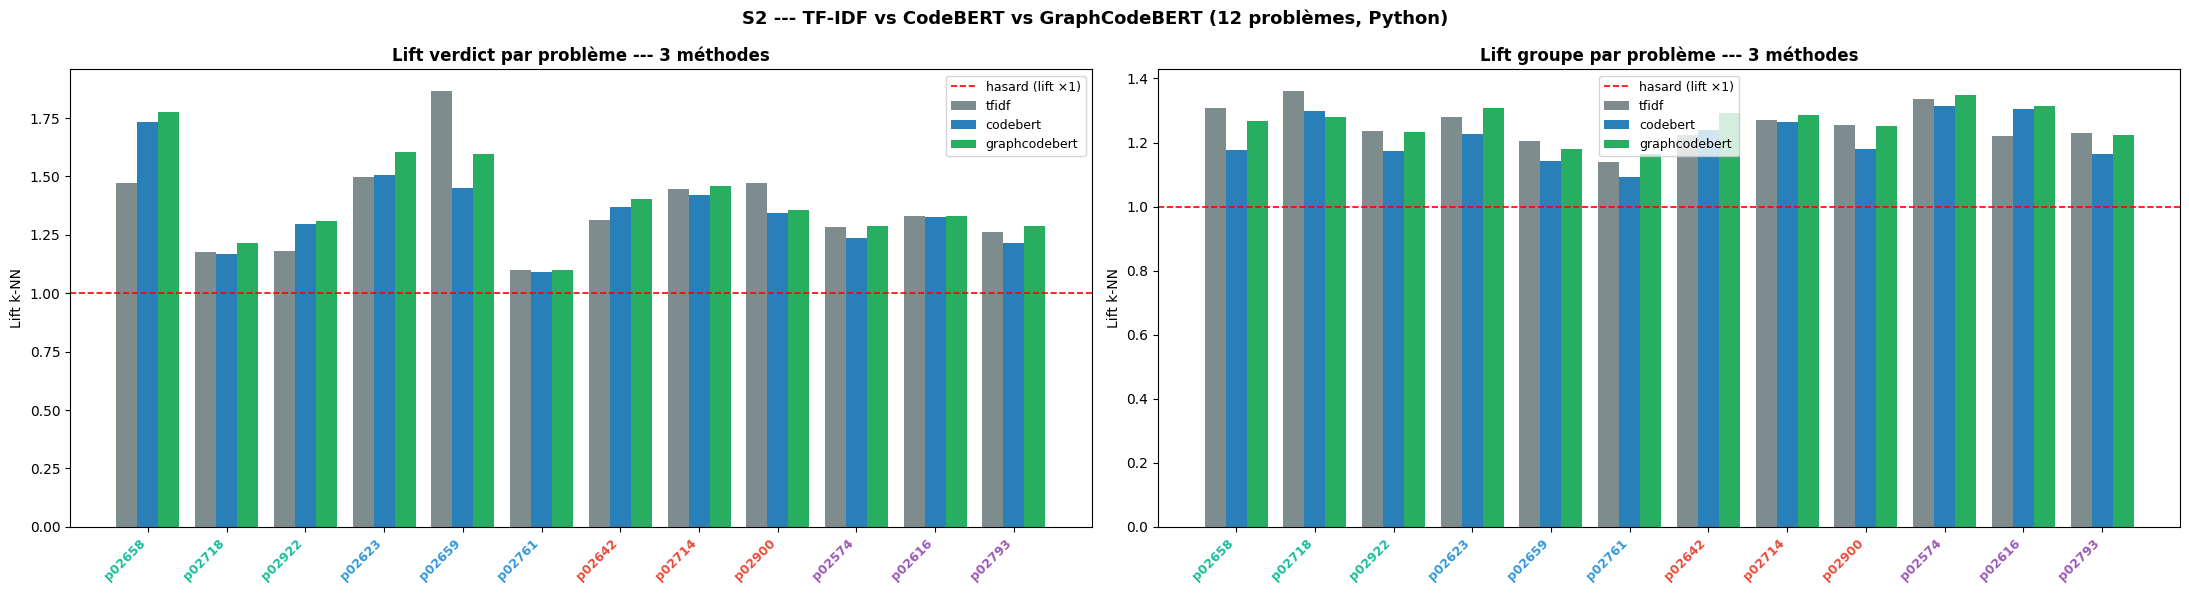

Moyenne des deltas par étiquette :
shape: (2, 4)
┌───────────────────┬──────────────────┬───────────────┬──────────────────┐
│ label             ┆ Δ codebert-tfidf ┆ Δ graph-tfidf ┆ Δ graph-codebert │
│ ---               ┆ ---              ┆ ---           ┆ ---              │
│ str               ┆ f64              ┆ f64           ┆ f64              │
╞═══════════════════╪══════════════════╪═══════════════╪══════════════════╡
│ proficiency_group ┆ -0.04054         ┆ 0.007561      ┆ 0.048101         │
│ status_code       ┆ -0.01954         ┆ 0.027806      ┆ 0.047345         │
└───────────────────┴──────────────────┴───────────────┴──────────────────┘

GraphCodeBERT bat CodeBERT sur combien de problèmes ?
  verdict  : 12/12 problèmes
  groupe   : 11/12 problèmes


In [9]:
problems_ordered = (
    df_s2_3.select(['problem_id', 'difficulty']).unique().sort(['difficulty', 'problem_id'])
)
pid_list  = problems_ordered['problem_id'].to_list()
diff_list = problems_ordered['difficulty'].to_list()

fig, axes = plt.subplots(1, len(TARGET_LABELS_S2), figsize=(11 * len(TARGET_LABELS_S2), 6))
if len(TARGET_LABELS_S2) == 1:
    axes = [axes]

x = np.arange(len(pid_list))
width = 0.8 / max(len(methods_present), 1)
offsets = np.linspace(-0.8 / 2 + width / 2, 0.8 / 2 - width / 2, len(methods_present))

for ax, label in zip(axes, TARGET_LABELS_S2):
    sub = df_s2_3.filter(pl.col('label') == label)

    for off, m in zip(offsets, methods_present):
        vals = []
        for pid in pid_list:
            row = sub.filter((pl.col('problem_id') == pid) & (pl.col('method') == m))
            vals.append(row['lift'][0] if row.height else np.nan)
        ax.bar(x + off, vals, width,
               label=m.replace('_python_multi12', ''), color=METHOD_COLORS.get(m, '#333'))

    ax.axhline(1.0, color='red', linestyle='--', linewidth=1.2, label='hasard (lift ×1)')
    ax.set_xticks(x)
    ax.set_xticklabels(pid_list, rotation=45, ha='right', fontsize=9)
    for tick, diff in zip(ax.get_xticklabels(), diff_list):
        tick.set_color(DIFF_COLORS.get(diff, 'black'))
        tick.set_fontweight('bold')
    ax.set_ylabel('Lift k-NN')
    ax.set_title(f'Lift {LABEL_NAMES_S2[label]} par problème --- 3 méthodes', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('S2 --- TF-IDF vs CodeBERT vs GraphCodeBERT (12 problèmes, Python)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Deltas : Δ(CodeBERT-TFIDF), Δ(GraphCodeBERT-TFIDF), Δ(GraphCodeBERT-CodeBERT) ---
piv = df_s2_3.pivot(on='method', index=['problem_id', 'difficulty', 'label'], values='lift')
piv = piv.rename({m: m.replace('_python_multi12', '') for m in methods_present})
piv = piv.with_columns([
    (pl.col('codebert') - pl.col('tfidf')).alias('d_code_tfidf'),
    (pl.col('graphcodebert') - pl.col('tfidf')).alias('d_graph_tfidf'),
    (pl.col('graphcodebert') - pl.col('codebert')).alias('d_graph_code'),
])

print("Moyenne des deltas par étiquette :")
print(piv.group_by('label').agg([
    pl.col('d_code_tfidf').mean().alias('Δ codebert-tfidf'),
    pl.col('d_graph_tfidf').mean().alias('Δ graph-tfidf'),
    pl.col('d_graph_code').mean().alias('Δ graph-codebert'),
]))

print("\nGraphCodeBERT bat CodeBERT sur combien de problèmes ?")
for lbl in TARGET_LABELS_S2:
    sub = piv.filter(pl.col('label') == lbl)
    wins = sub.filter(pl.col('d_graph_code') > 0).height
    print(f"  {LABEL_NAMES_S2[lbl]:8s} : {wins}/{sub.height} problèmes")

## S3 --- Heatmaps de confusion par voisinage
### S3 --- Neighbor Confusion Heatmaps

Reprise directe de la méthode S6.2 de NB11 --- sans projection, la vue la plus
fiable. Mêmes deux problèmes de référence que NB11 (p02659 : lift verdict le plus
élevé du criblage TF-IDF/CodeBERT ; p02658 : seul cas où CodeBERT dépassait
nettement TF-IDF), pour rester directement comparable aux résultats déjà obtenus
--- on ajoute simplement une troisième ligne (GraphCodeBERT) à une grille déjà
connue.

---

Direct reuse of NB11's S6.2 method --- no projection, the most reliable view.
Same two reference problems as NB11 (p02659: highest verdict lift in the
TF-IDF/CodeBERT screening; p02658: the only case where CodeBERT clearly beat
TF-IDF), to stay directly comparable to results already obtained --- we simply add
a third row (GraphCodeBERT) to an already-familiar grid.

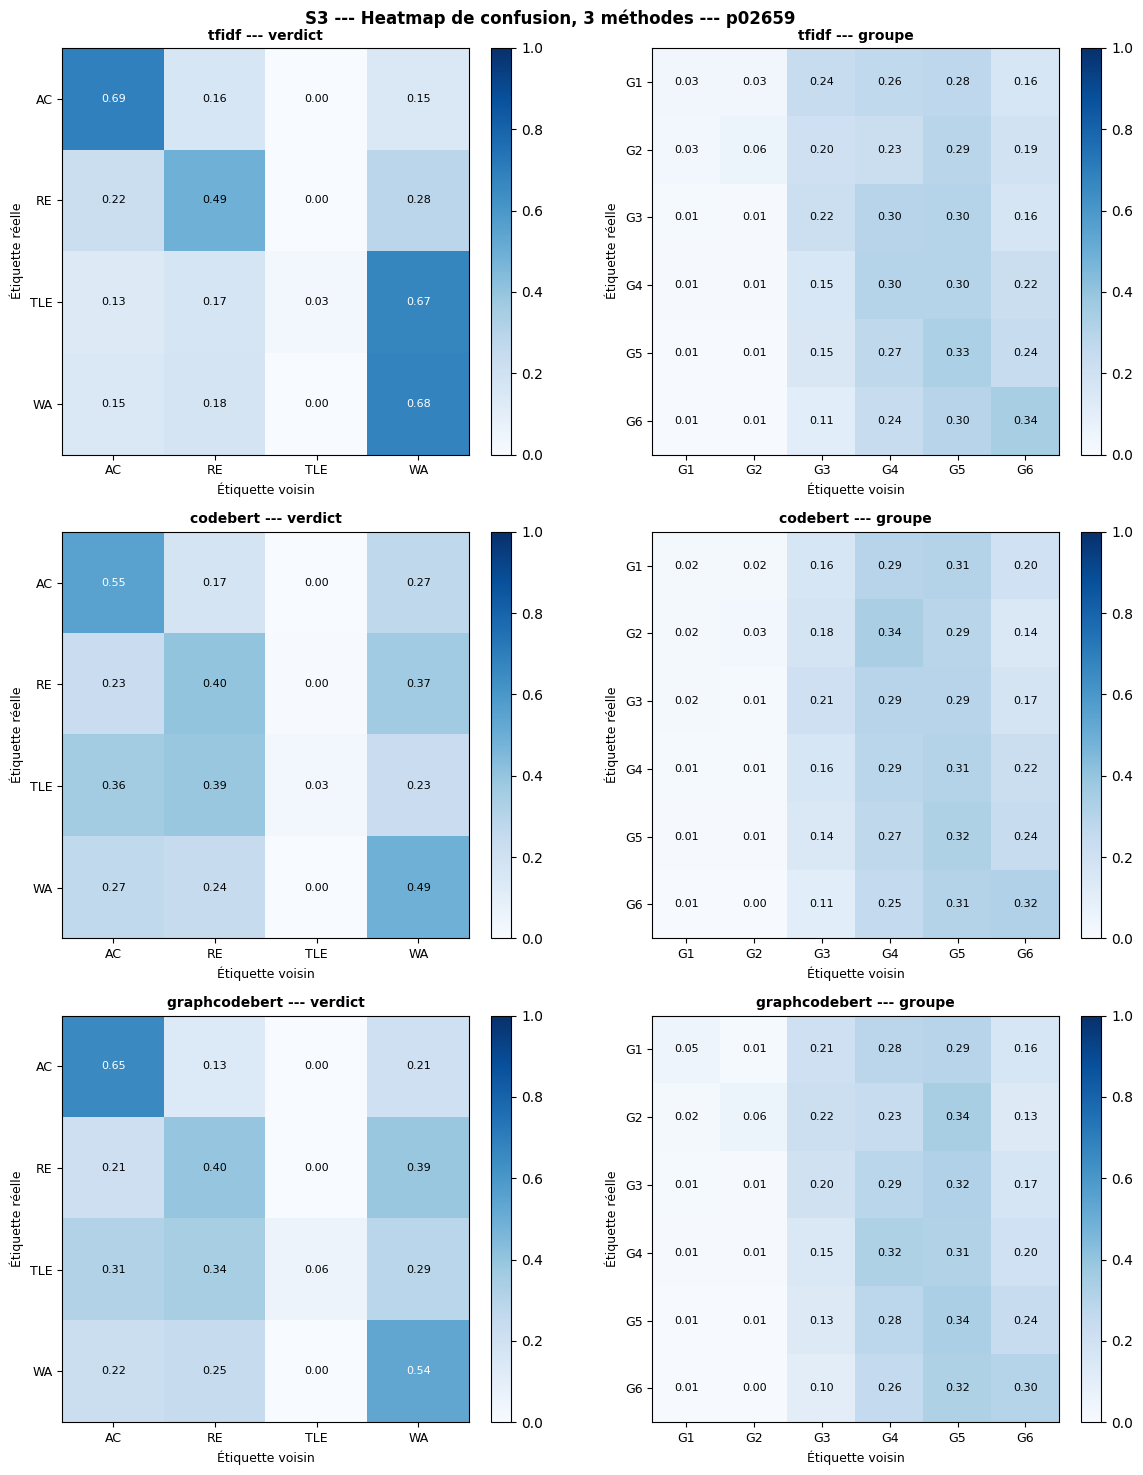

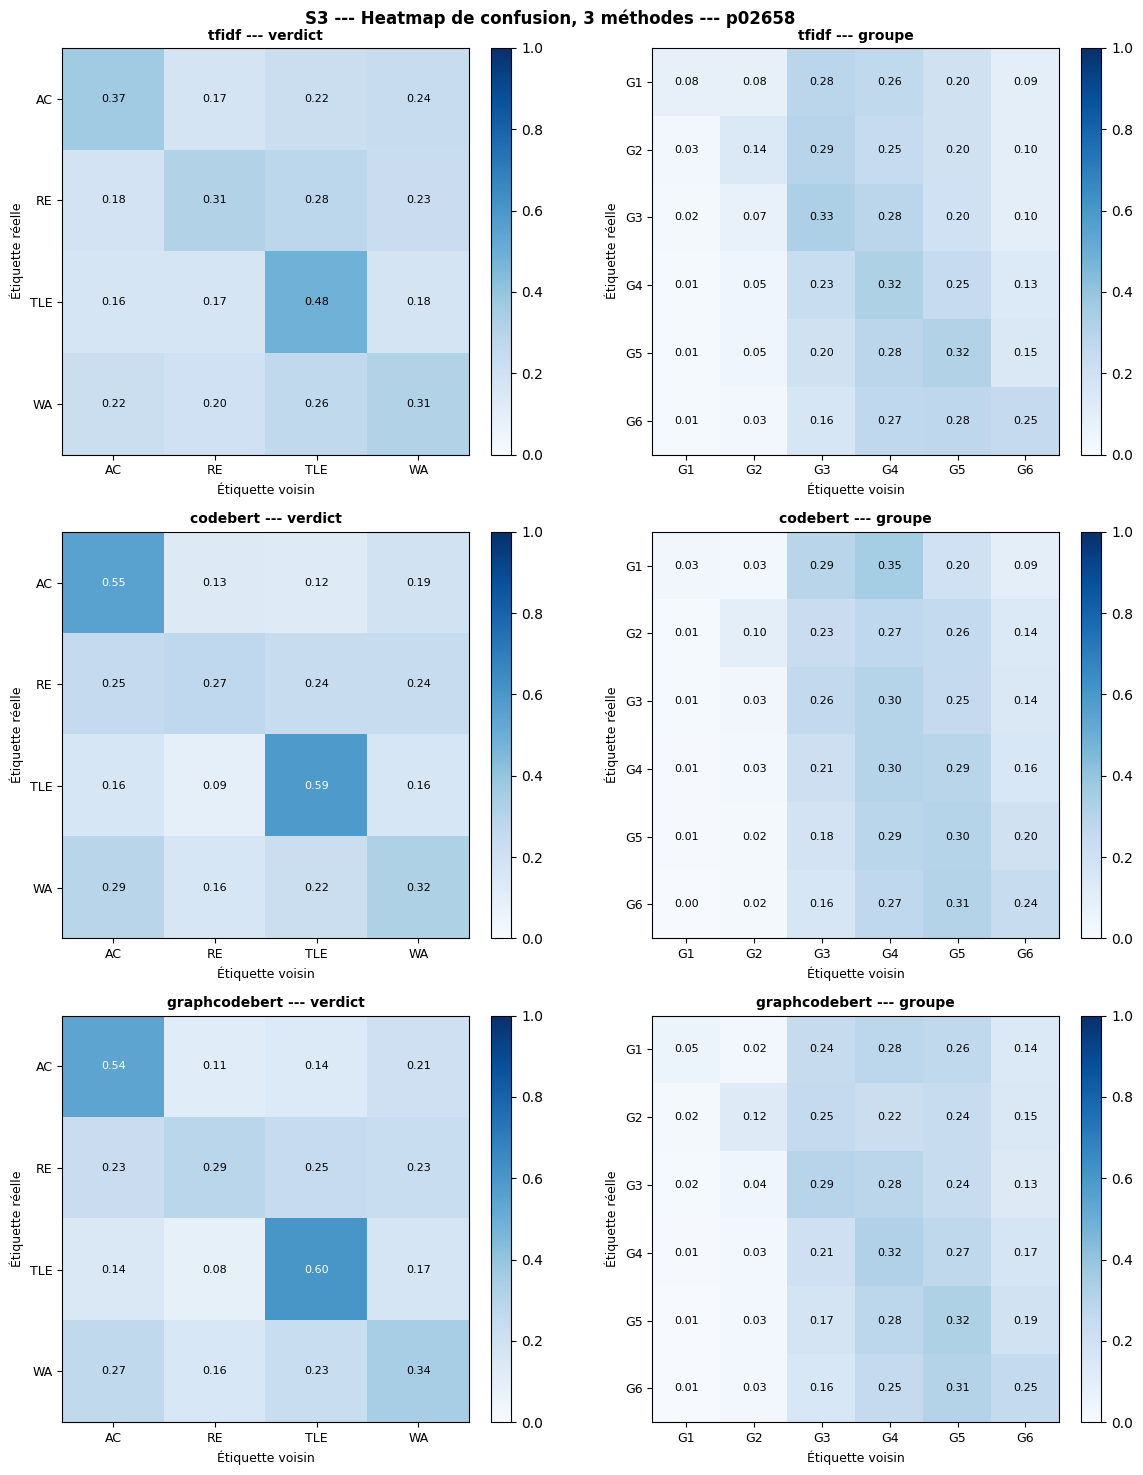

In [10]:
from sklearn.neighbors import NearestNeighbors as _NNs3

TARGETS_S3 = ['p02659', 'p02658']

for pid in TARGETS_S3:
    fig, axes = plt.subplots(len(methods_present), len(TARGET_LABELS_S2),
                             figsize=(6 * len(TARGET_LABELS_S2), 5 * len(methods_present)))
    axes = np.atleast_2d(axes)
    if axes.shape != (len(methods_present), len(TARGET_LABELS_S2)):
        axes = axes.reshape(len(methods_present), len(TARGET_LABELS_S2))

    for row_i, m in enumerate(methods_present):
        meta = df_meta_3[m]
        idx = np.where((meta['problem_id'] == pid).to_numpy())[0]
        sub_emb = embeddings_3[m][idx]
        sub_meta = meta[idx]

        nbrs = _NNs3(n_neighbors=K + 1, metric='cosine', algorithm='brute', n_jobs=-1)
        nbrs.fit(sub_emb)
        _, nn_idx = nbrs.kneighbors(sub_emb)

        for col_i, label in enumerate(TARGET_LABELS_S2):
            ax = axes[row_i, col_i]
            labels_arr = sub_meta[label].to_numpy()
            classes = sorted(set(labels_arr))
            cls_idx = {c: i for i, c in enumerate(classes)}
            n_cls = len(classes)

            matrix = np.zeros((n_cls, n_cls), dtype=float)
            for i, true_v in enumerate(labels_arr):
                for j in nn_idx[i, 1:]:
                    matrix[cls_idx[true_v], cls_idx[labels_arr[j]]] += 1
            row_sums = matrix.sum(axis=1, keepdims=True)
            row_sums[row_sums == 0] = 1
            matrix /= row_sums

            im = ax.imshow(matrix, vmin=0, vmax=1, cmap='Blues')
            ax.set_xticks(range(n_cls)); ax.set_xticklabels(classes, fontsize=9)
            ax.set_yticks(range(n_cls)); ax.set_yticklabels(classes, fontsize=9)
            ax.set_xlabel('Étiquette voisin', fontsize=9)
            ax.set_ylabel('Étiquette réelle', fontsize=9)
            ax.set_title(f'{m.replace("_python_multi12", "")} --- {LABEL_NAMES_S2[label]}',
                        fontsize=10, fontweight='bold')
            for r in range(n_cls):
                for c in range(n_cls):
                    ax.text(c, r, f'{matrix[r,c]:.2f}', ha='center', va='center',
                            fontsize=8, color='white' if matrix[r,c] > 0.5 else 'black')
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.suptitle(f'S3 --- Heatmap de confusion, 3 méthodes --- {pid}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

## S4 --- Cartes UMAP : un problème par difficulté
### S4 --- UMAP Maps: One Problem per Difficulty

**Pourquoi revenir sur UMAP alors qu'on l'avait écarté.** NB11 S6 a montré qu'UMAP,
utilisé seul, ne montrait *aucune* séparation visuelle même sur le lift verdict le
plus élevé de tout le corpus (p02659, ×1,87 en TF-IDF) --- un résultat qu'on avait
attribué à sa tendance à préserver une structure globale continue plutôt que des
îlots locaux nets. On le réintroduit ici volontairement, **à côté** de t-SNE (S5)
sur les mêmes problèmes, pour donner une preuve visuelle directe de cette
différence plutôt que de se contenter de l'affirmer : les deux méthodes projettent
exactement les mêmes points, seul l'algorithme de projection change.

**Sélection des problèmes.** Plutôt que les deux extrêmes globaux de NB11
(p02659, p02658), on prend ici **un problème par difficulté (B à E)**, celui où
l'écart Δ(GraphCodeBERT − CodeBERT) est le plus grand dans sa tranche --- c'est-à-dire
là où l'avantage de GraphCodeBERT sur CodeBERT, mesuré en S2, est le plus net à
chaque niveau. Cela donne une image représentative de l'ensemble de la difficulté,
pas seulement du cas le plus favorable toutes difficultés confondues :

| Difficulté | Problème | Δ(GraphCodeBERT − CodeBERT), verdict |
|---|---|---|
| B | p02718 | +0,048 |
| C | p02659 | +0,143 (le plus grand écart de tout le tableau S2) |
| D | p02714 | +0,038 |
| E | p02793 | +0,073 |

(p02659 --- déjà utilisé en S3 --- reste donc présent, par coïncidence il est aussi
le meilleur cas de sa propre difficulté.)

---

**Why bring UMAP back after setting it aside.** NB11 S6 showed that UMAP, used
alone, showed *no* visual separation even for the highest verdict lift in the
whole corpus (p02659, ×1.87 for TF-IDF) --- a result attributed to its tendency to
preserve a continuous global structure rather than sharp local islands. It is
brought back here deliberately, **alongside** t-SNE (S5) on the same problems, to
give direct visual proof of this difference rather than simply asserting it: both
methods project the exact same points, only the projection algorithm changes.

**Problem selection.** Rather than NB11's two global extremes (p02659, p02658),
we take **one problem per difficulty (B to E)** here, the one where the
Δ(GraphCodeBERT − CodeBERT) gap is largest within its band --- i.e. where
GraphCodeBERT's edge over CodeBERT, measured in S2, is clearest at each level.
This gives a representative picture across the whole difficulty range, not just
the single most favorable case overall (see table above; p02659 --- already used
in S3 --- happens to also be the best case within its own difficulty band).

/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


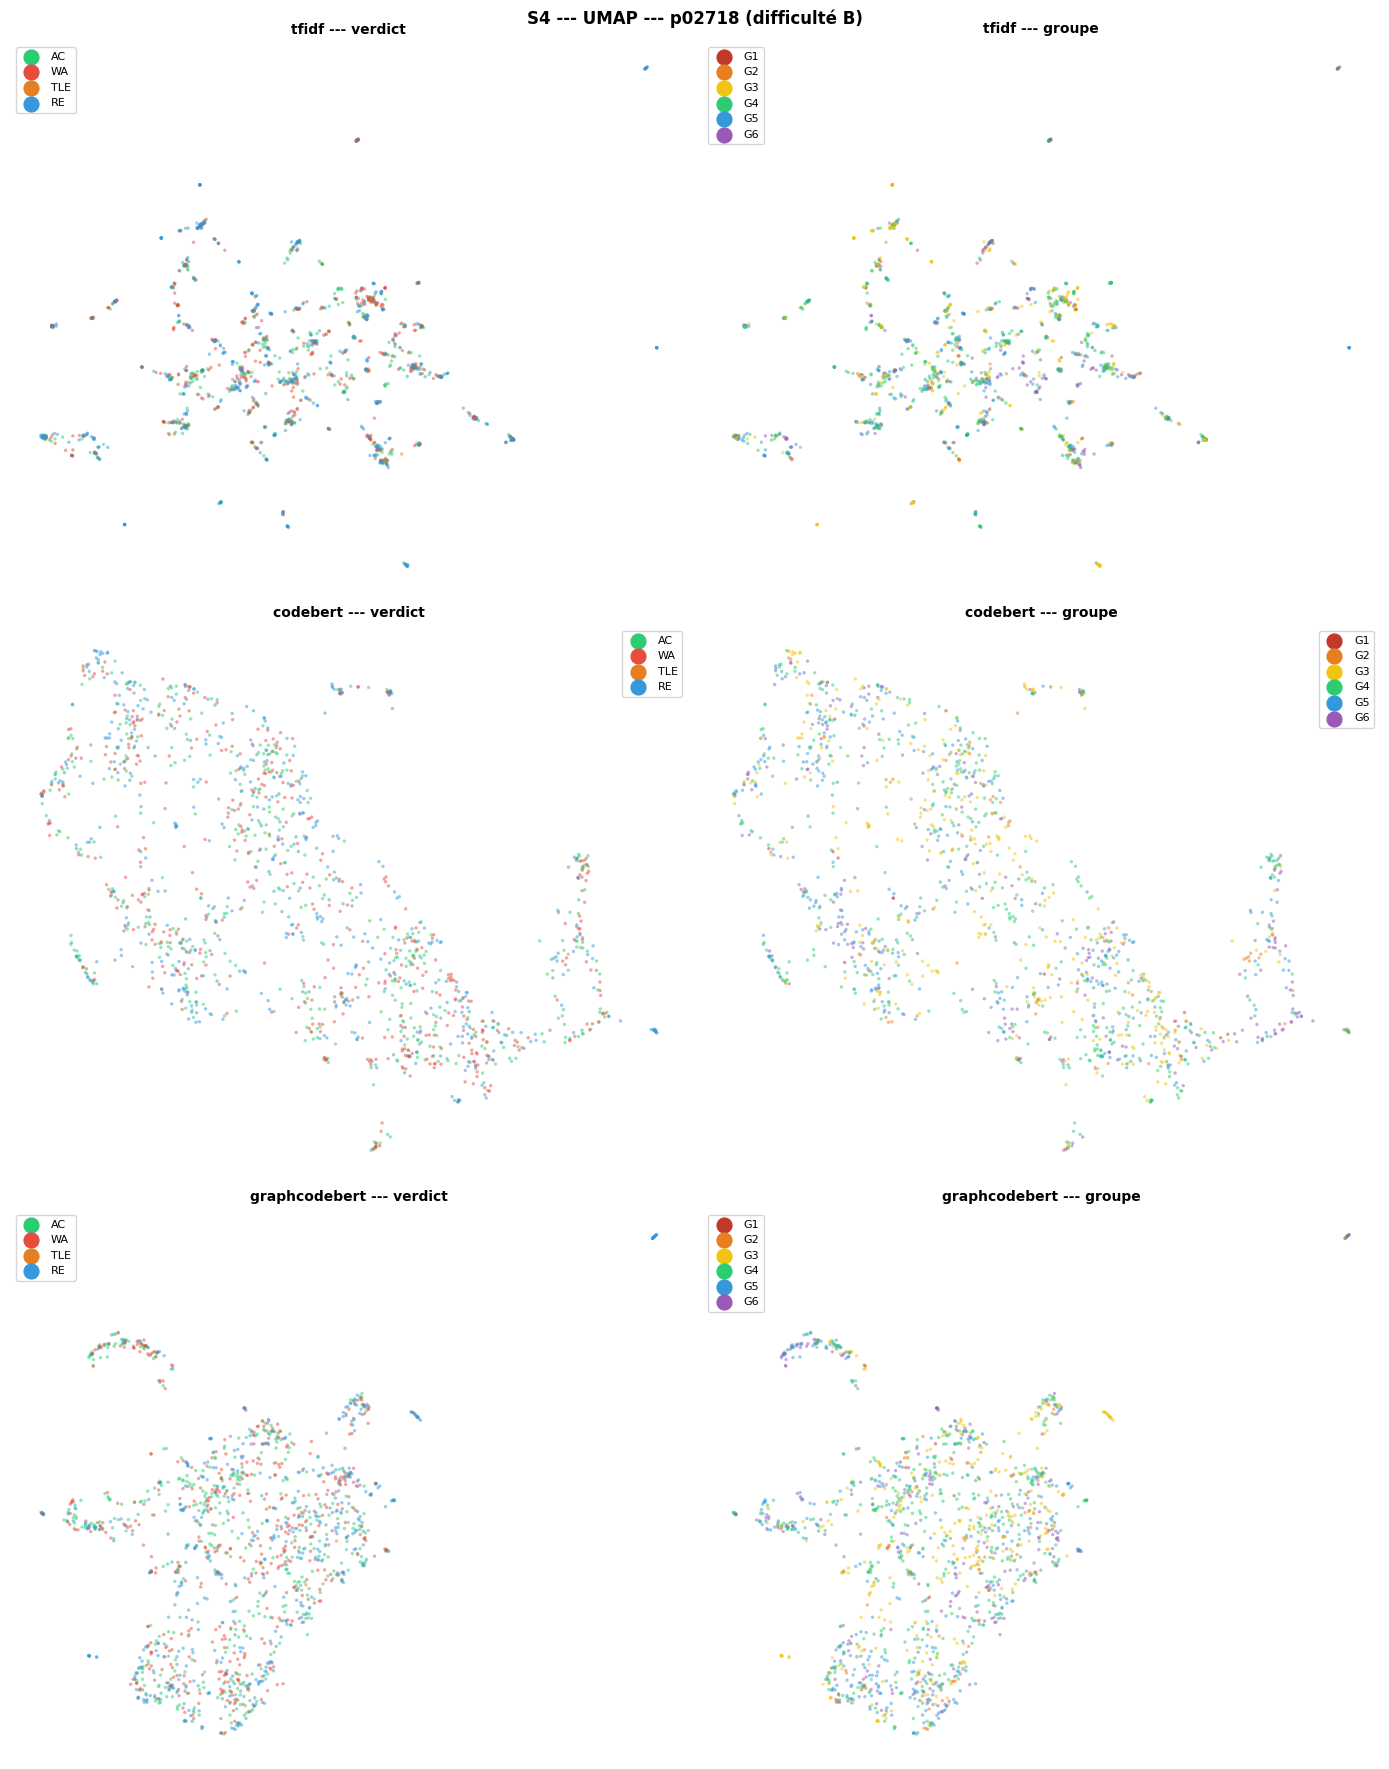

/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


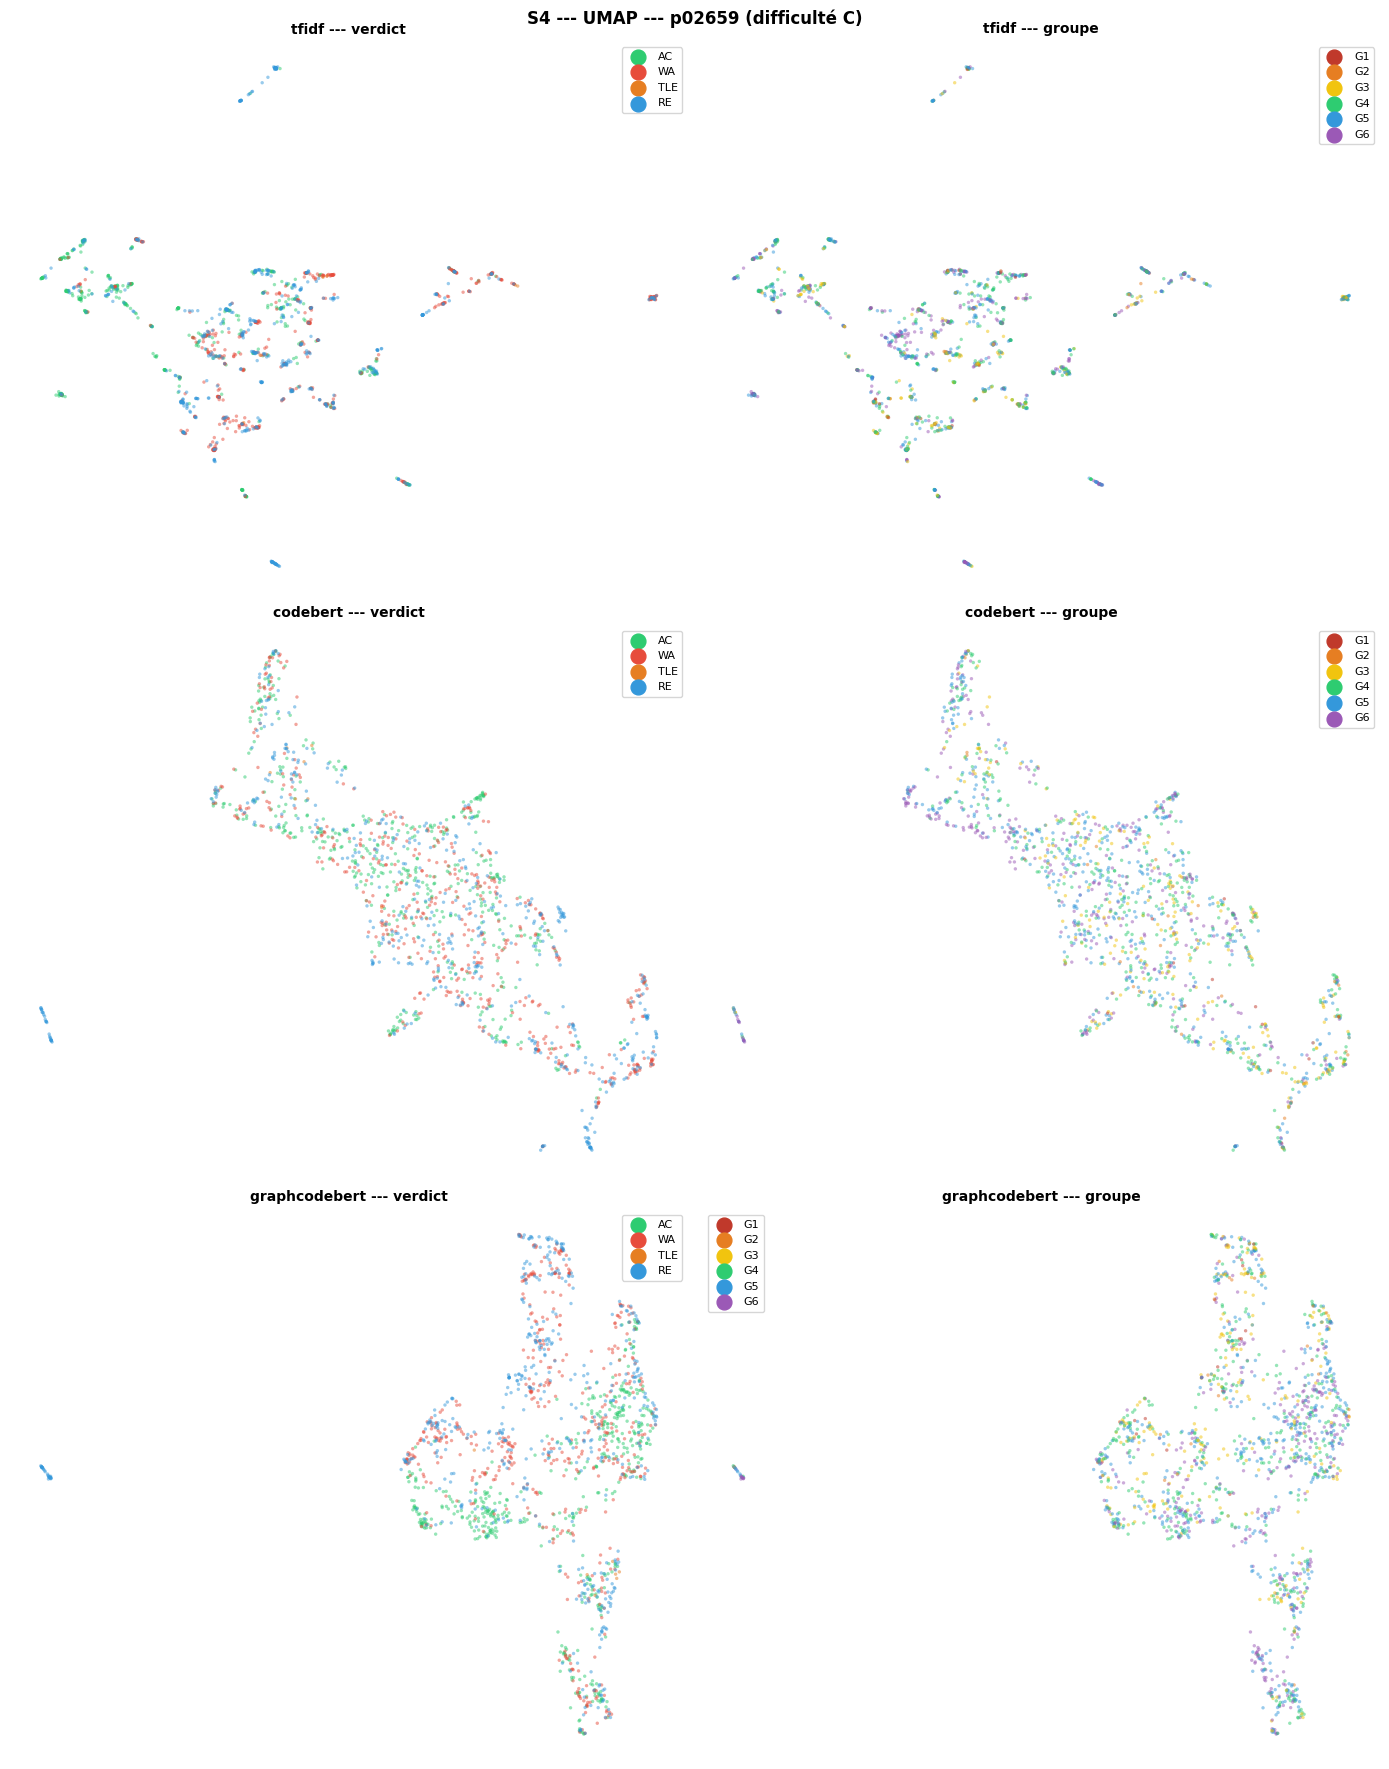

/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


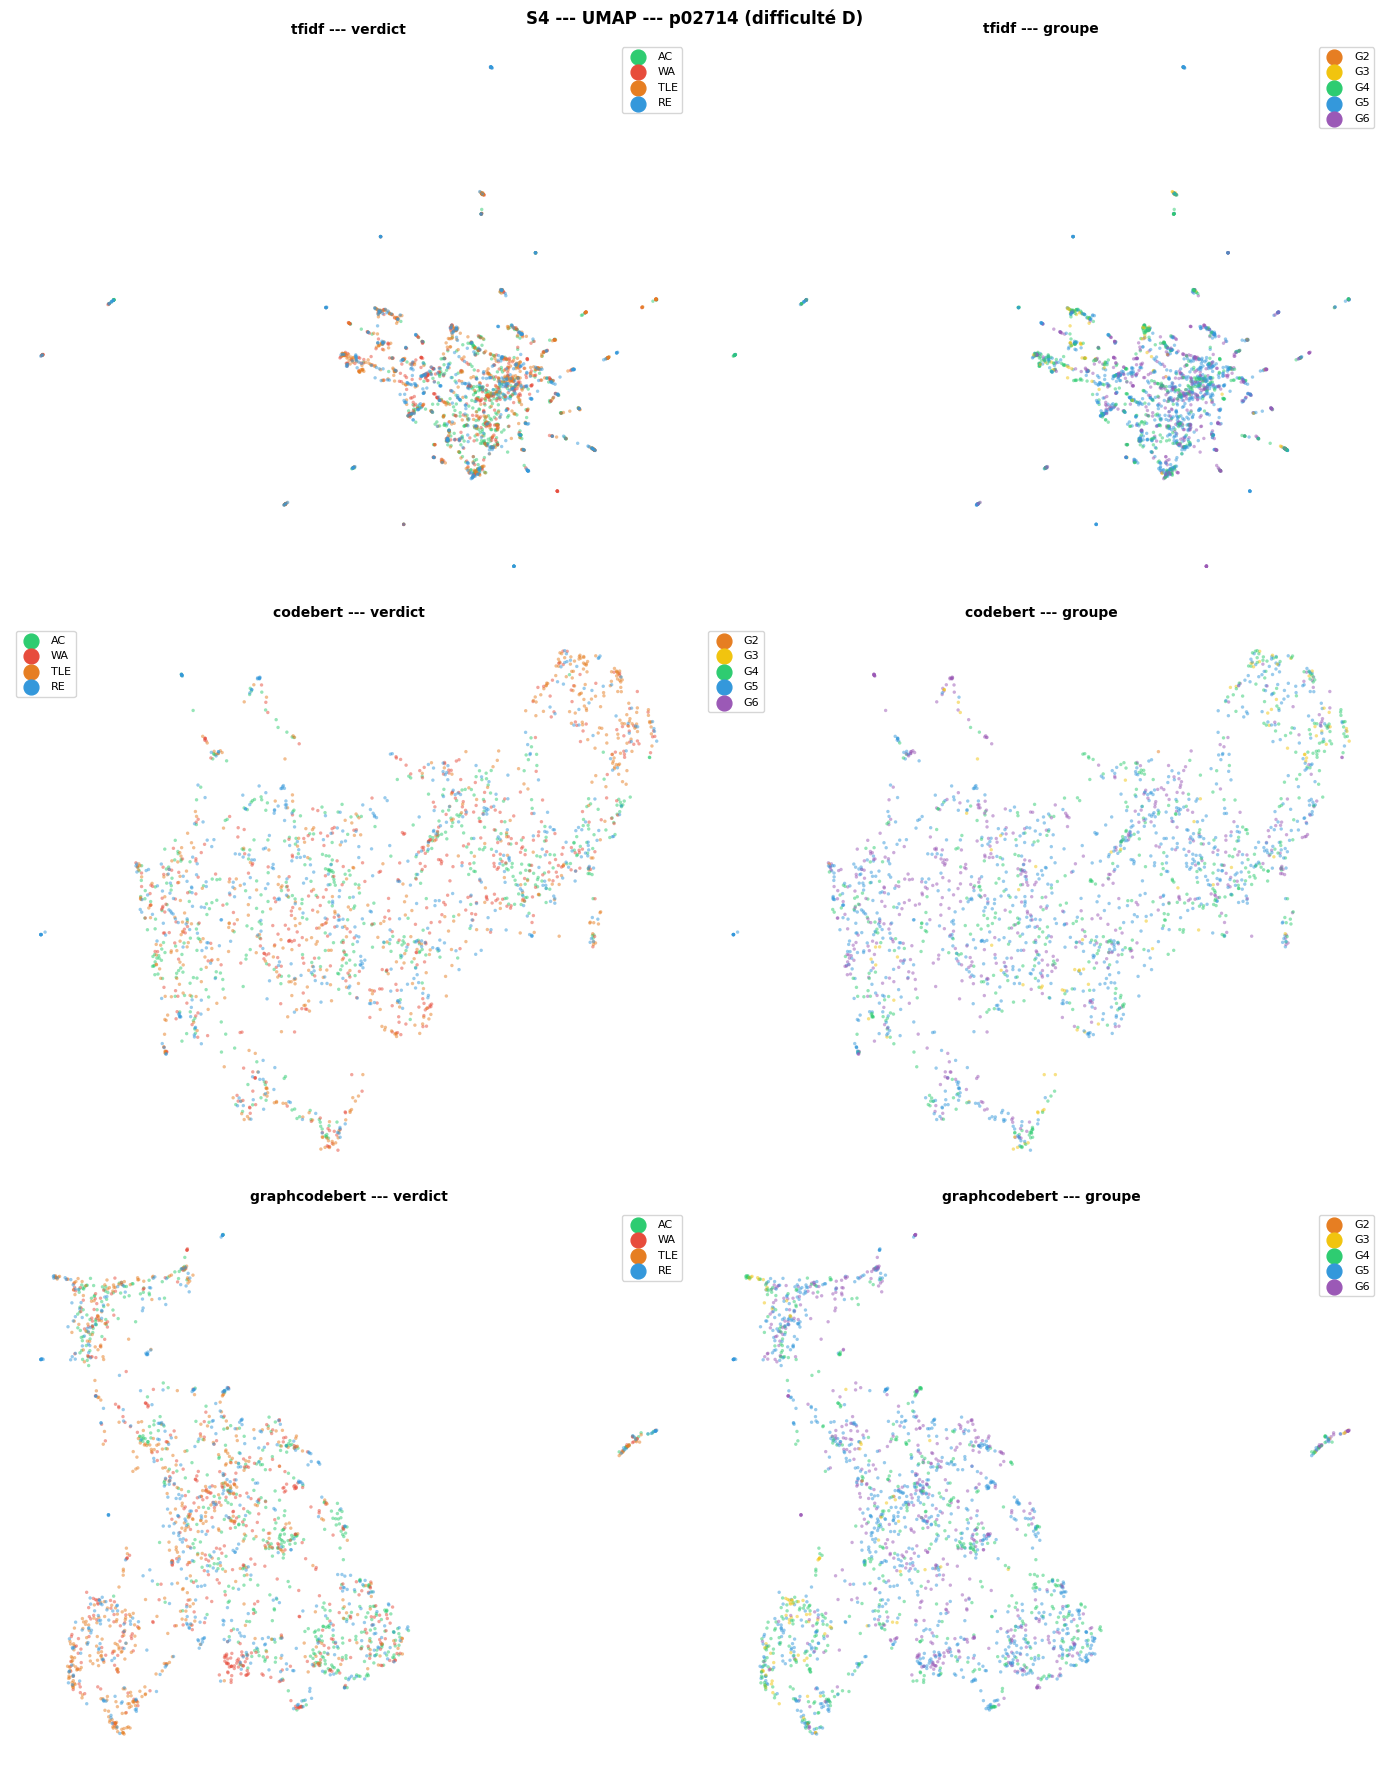

/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


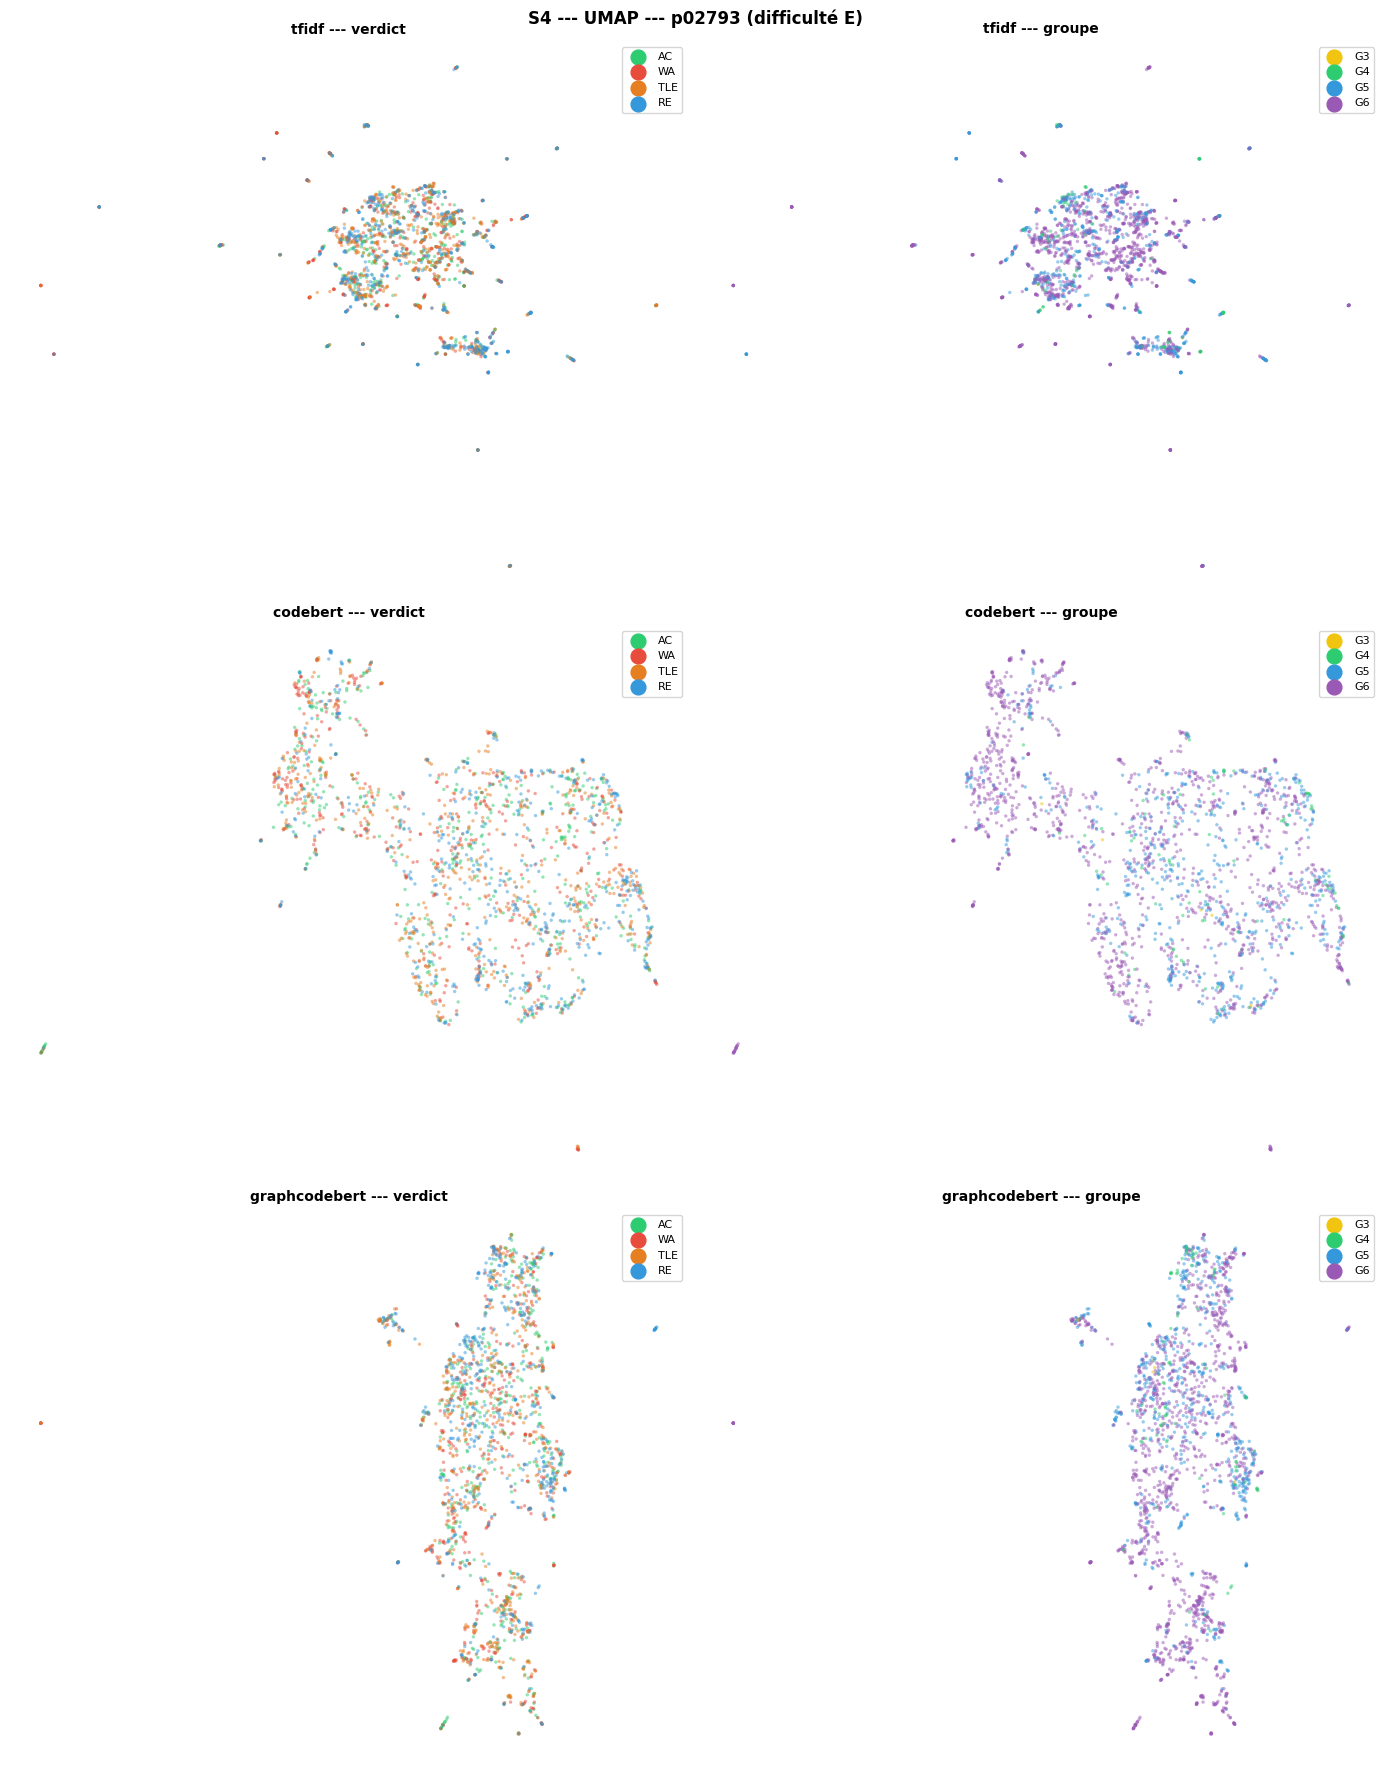

In [11]:
import umap

BEST_PER_DIFF = {'B': 'p02718', 'C': 'p02659', 'D': 'p02714', 'E': 'p02793'}
TARGETS_S4 = list(BEST_PER_DIFF.values())

for diff, pid in BEST_PER_DIFF.items():
    fig, axes = plt.subplots(len(methods_present), len(TARGET_LABELS_S2),
                             figsize=(7 * len(TARGET_LABELS_S2), 6 * len(methods_present)))
    axes = np.atleast_2d(axes)
    if axes.shape != (len(methods_present), len(TARGET_LABELS_S2)):
        axes = axes.reshape(len(methods_present), len(TARGET_LABELS_S2))

    for row_i, m in enumerate(methods_present):
        meta = df_meta_3[m]
        idx = np.where((meta['problem_id'] == pid).to_numpy())[0]
        sub_emb = embeddings_3[m][idx]
        sub_meta = meta[idx]

        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
                            random_state=42, metric='cosine')
        proj = reducer.fit_transform(sub_emb)

        for col_i, label in enumerate(TARGET_LABELS_S2):
            ax = axes[row_i, col_i]
            colors_map = STATUS_COLORS if label == 'status_code' else GROUP_COLORS
            order = STATUSES_ORDER if label == 'status_code' else GROUPS_ORDER
            vals = sub_meta[label].to_list()
            ax.scatter(proj[:, 0], proj[:, 1],
                      c=[colors_map.get(v, '#aaaaaa') for v in vals],
                      s=6, alpha=0.5, linewidths=0)
            for v in order:
                if v in vals:
                    ax.scatter([], [], c=colors_map[v], s=35, label=v)
            ax.legend(fontsize=8, markerscale=1.8, framealpha=0.8)
            ax.set_title(f'{m.replace("_python_multi12", "")} --- {LABEL_NAMES_S2[label]}',
                        fontsize=10, fontweight='bold')
            ax.axis('off')

    plt.suptitle(f'S4 --- UMAP --- {pid} (difficulté {diff})', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

## S5 --- Cartes t-SNE : mêmes 4 problèmes, autre projection
### S5 --- t-SNE Maps: Same 4 Problems, Different Projection

Rappel du mécanisme (détaillé en NB11 S6) : t-SNE utilise une loi de Student à
queue épaisse dans l'espace de sortie, ce qui autorise des points dissemblables à
être repoussés plus loin qu'ils ne le seraient sous UMAP --- au prix d'une
fragmentation plus agressive, parfois excessive, de la structure locale. Résultat
typique : là où UMAP produit un nuage continu, t-SNE tend à produire de petits
îlots compacts, davantage en phase avec ce que mesure le lift k-NN (une notion
strictement locale, k=10).

Mêmes 4 problèmes que S4, même disposition, pour une comparaison panneau par
panneau directe entre les deux méthodes de projection.

---

Reminder of the mechanism (detailed in NB11 S6): t-SNE uses a heavy-tailed Student
distribution in the output space, which allows dissimilar points to be pushed
further apart than they would be under UMAP --- at the cost of a more aggressive,
sometimes excessive, fragmentation of local structure. Typical result: where UMAP
produces a continuous cloud, t-SNE tends to produce small, tight islands, more in
line with what k-NN lift actually measures (a strictly local notion, k=10).

Same 4 problems as S4, same layout, for a direct panel-by-panel comparison
between the two projection methods.

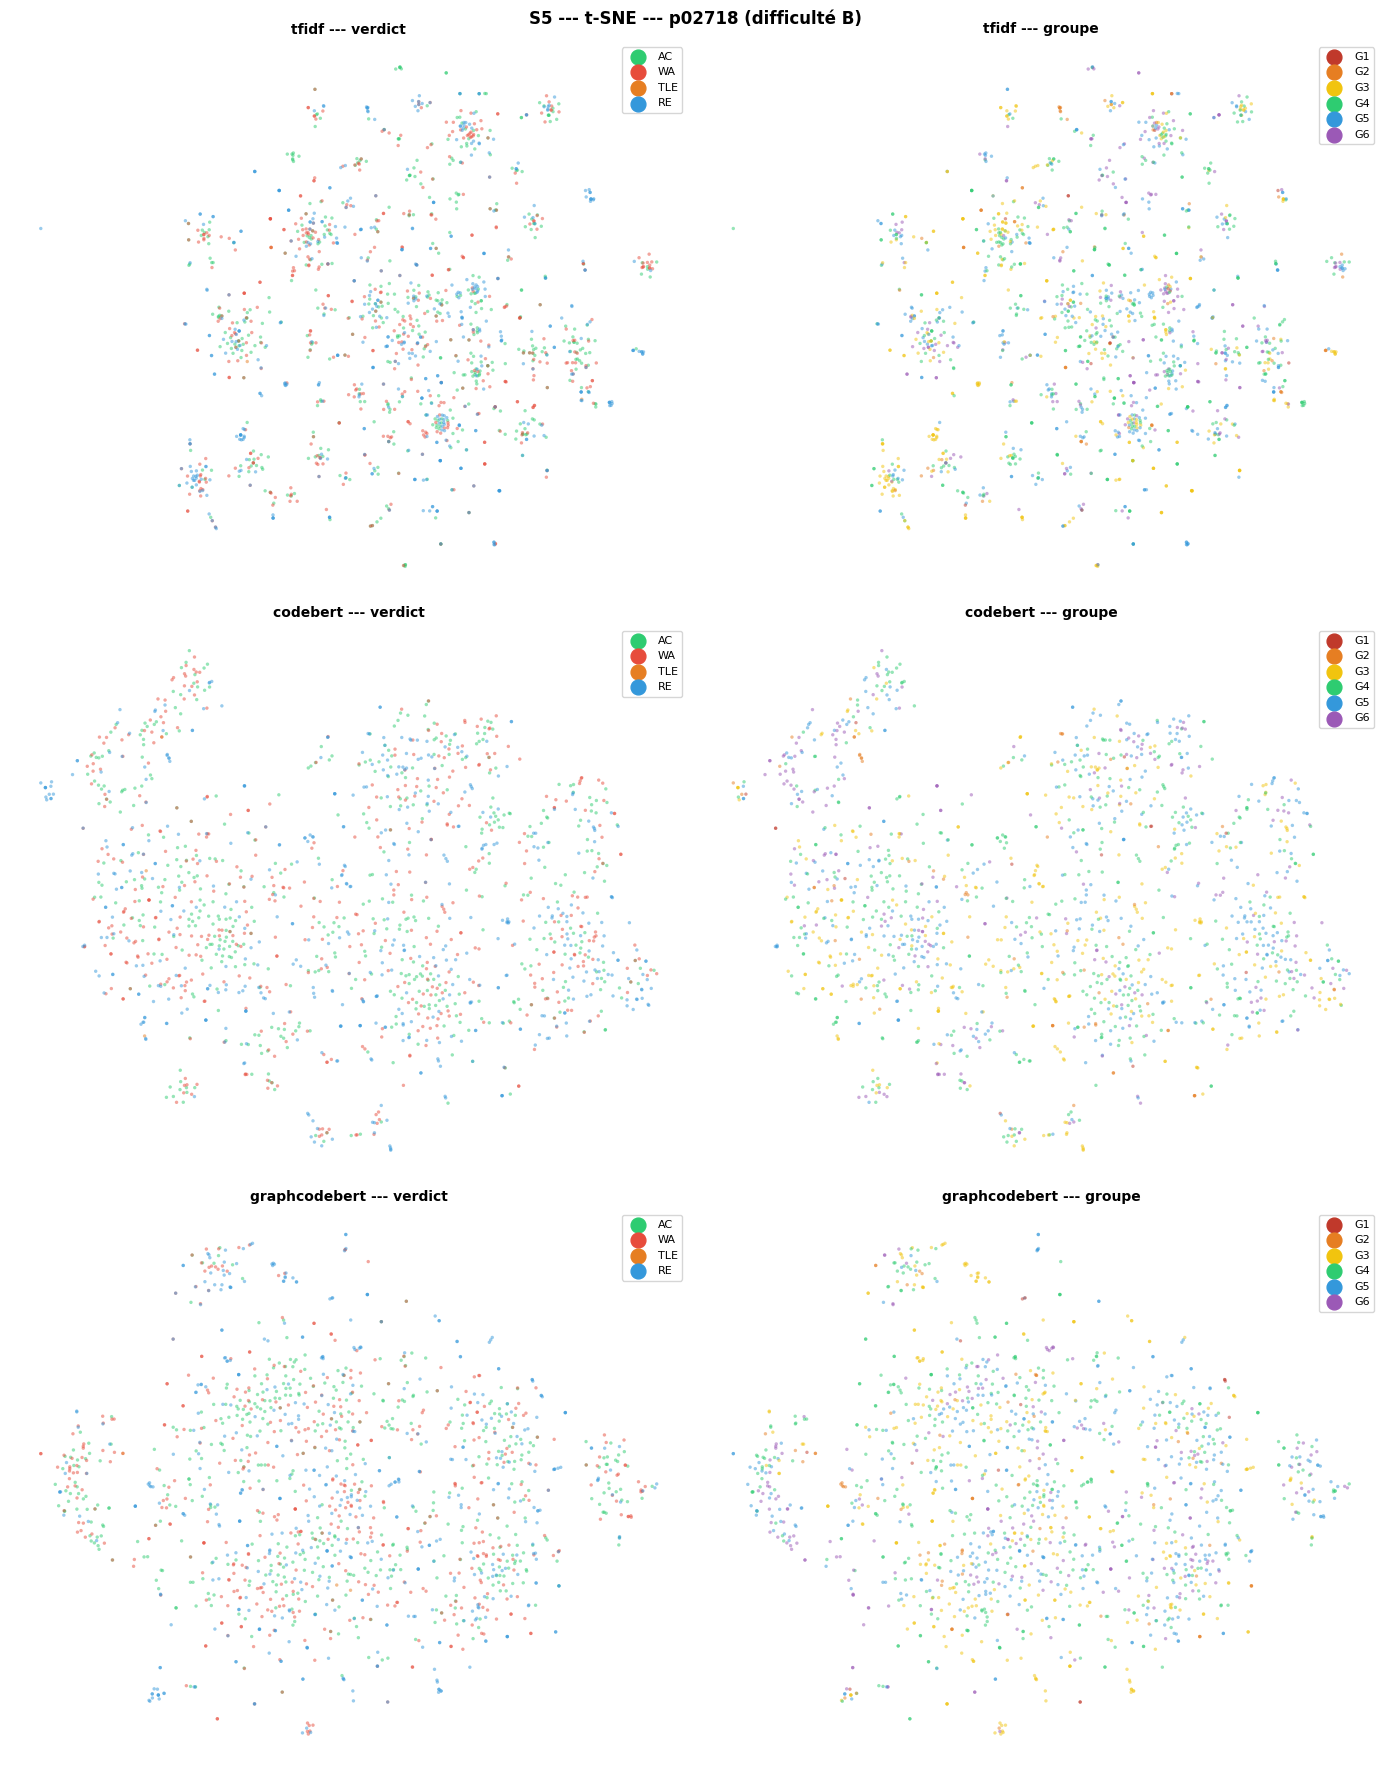

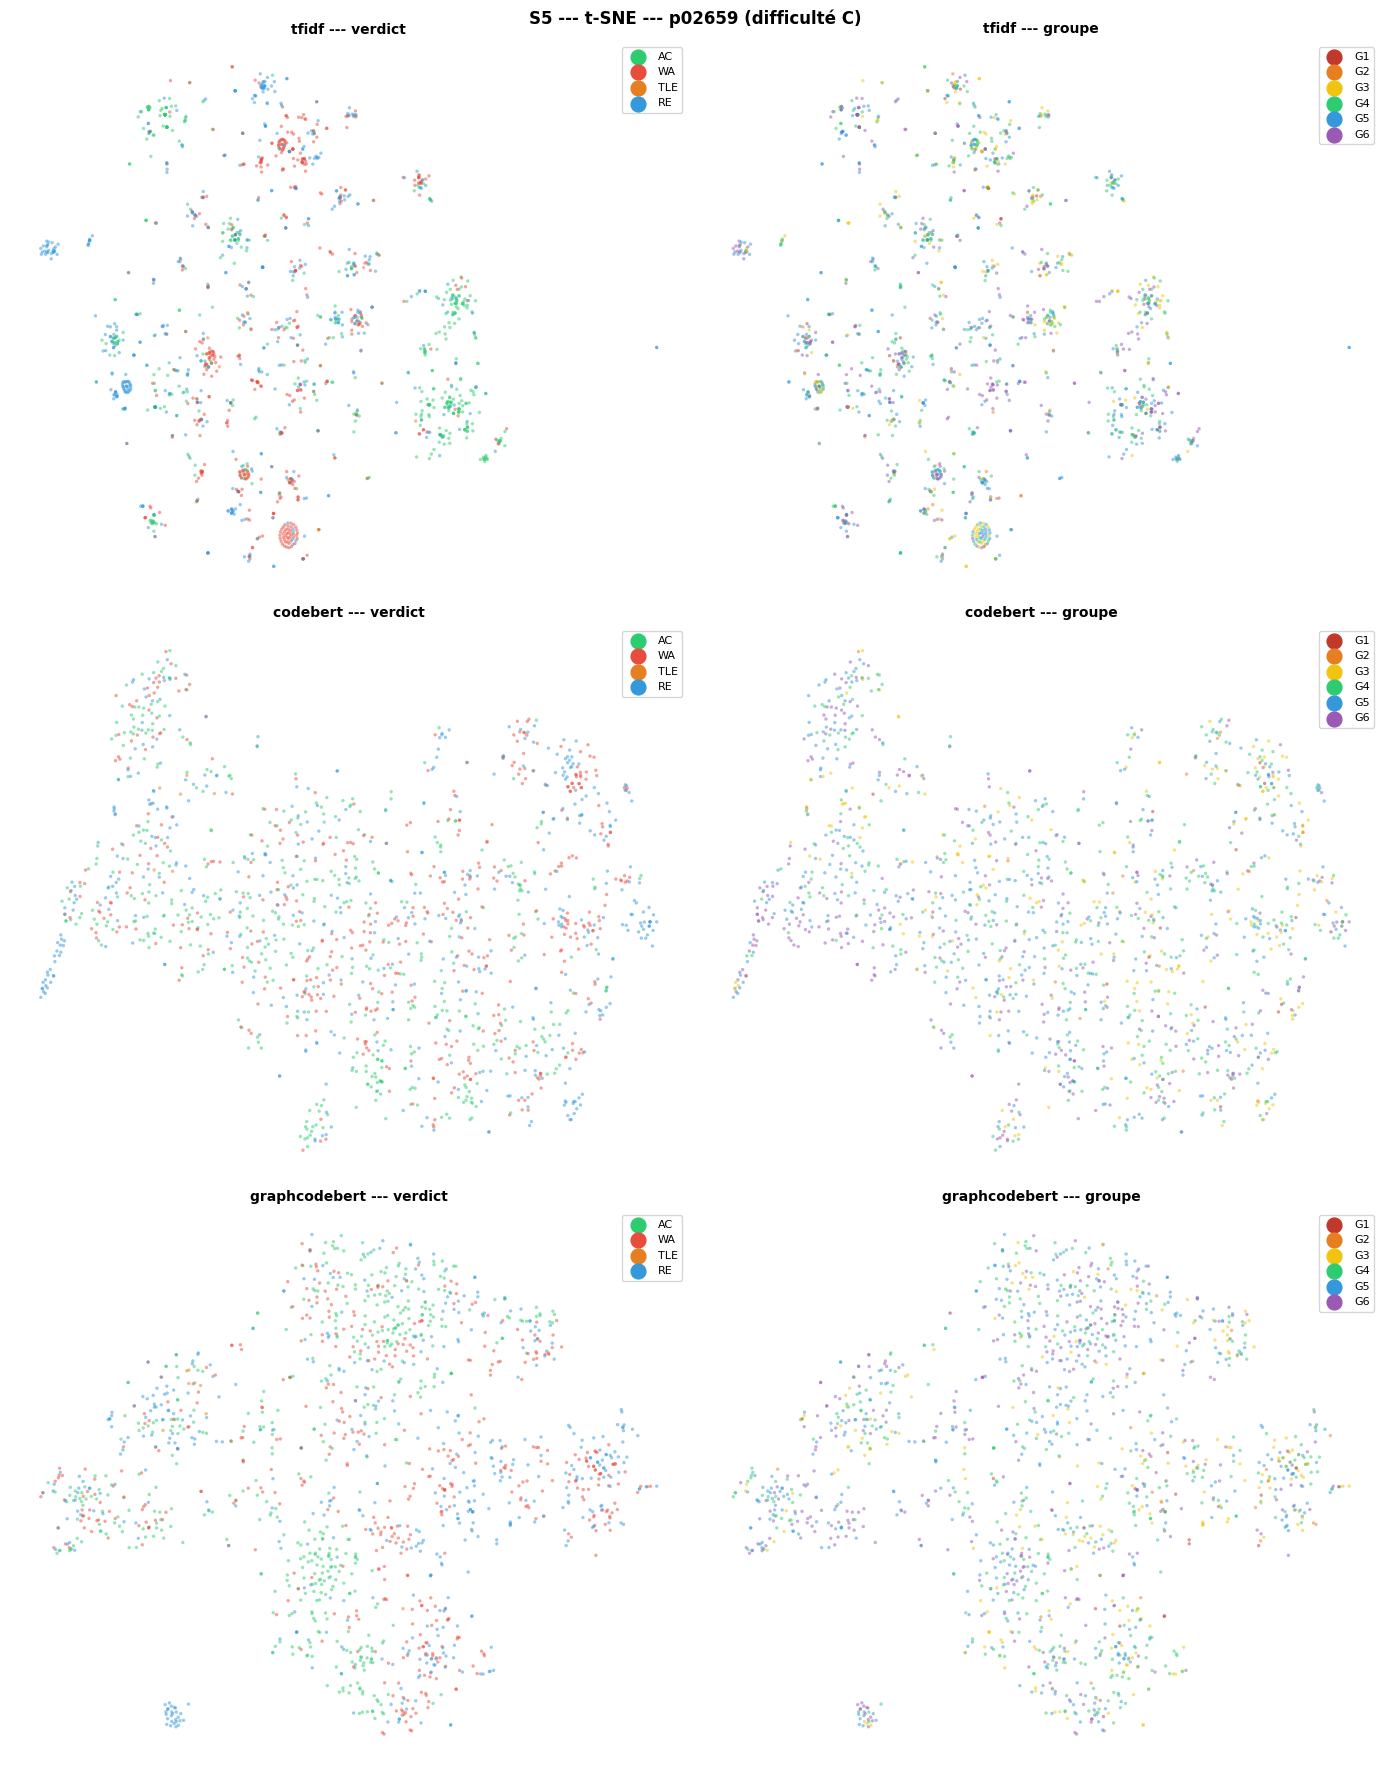

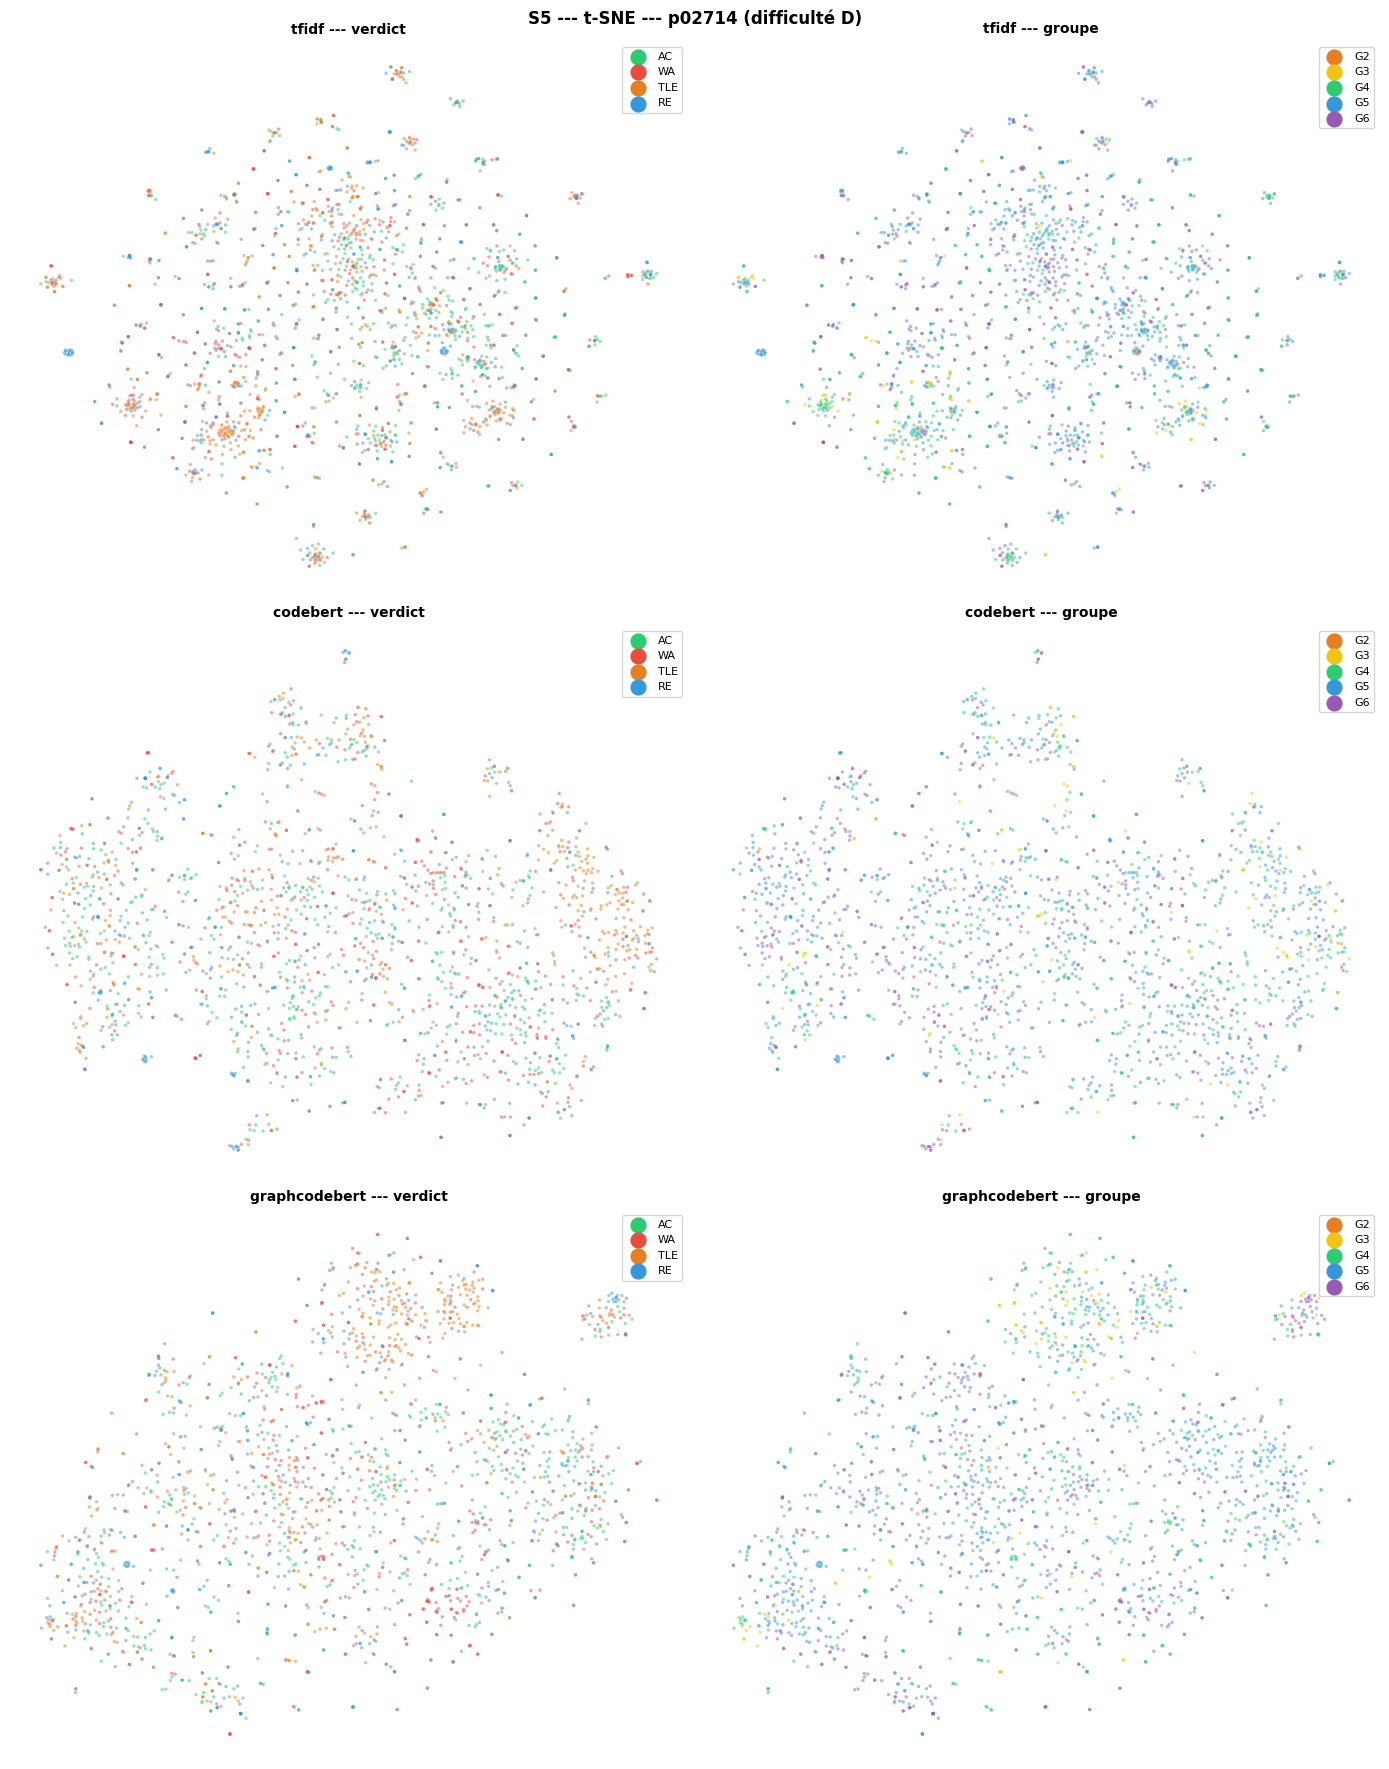

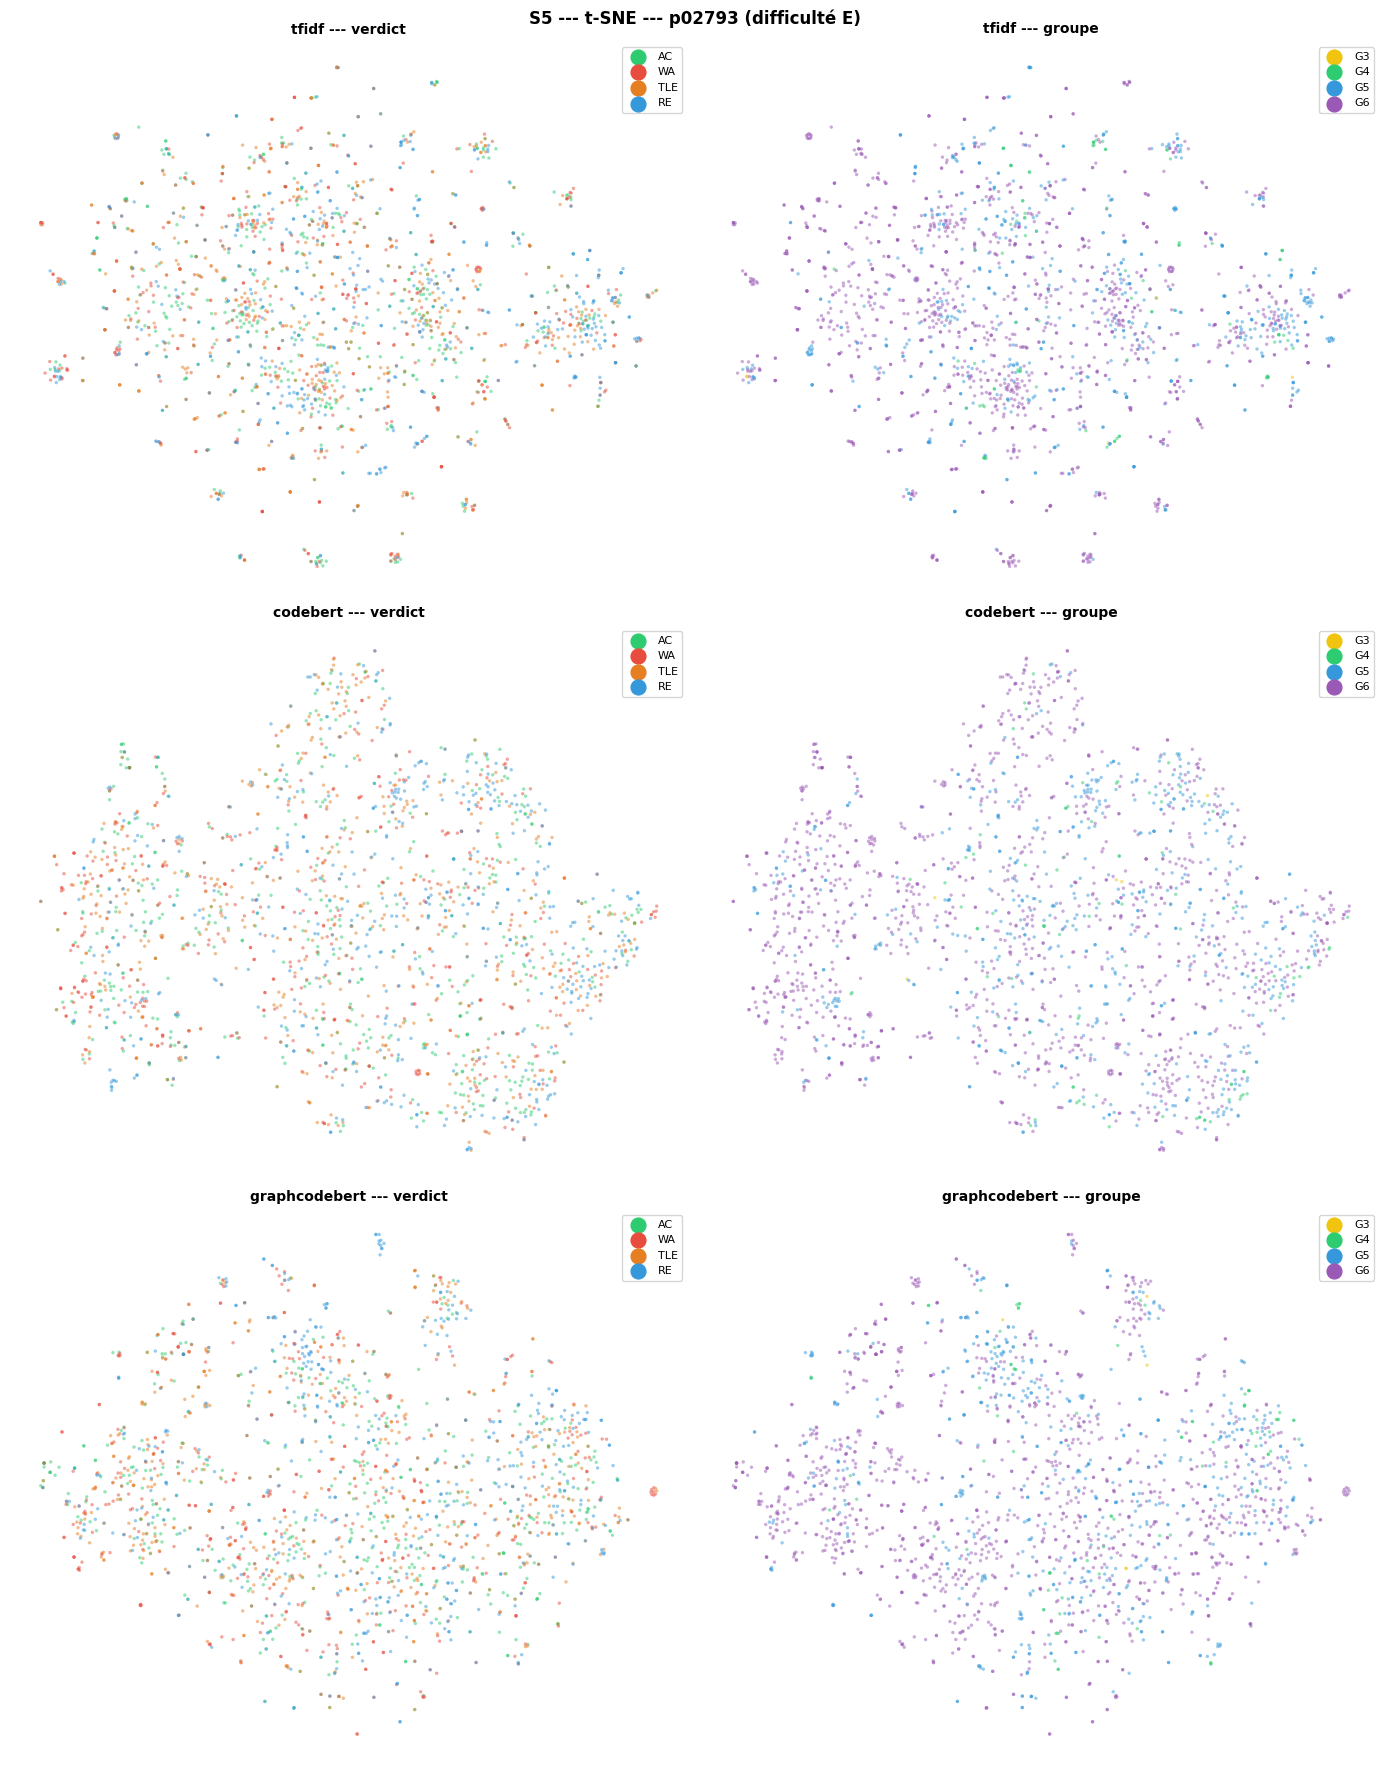

In [12]:
from sklearn.manifold import TSNE

for diff, pid in BEST_PER_DIFF.items():
    fig, axes = plt.subplots(len(methods_present), len(TARGET_LABELS_S2),
                             figsize=(7 * len(TARGET_LABELS_S2), 6 * len(methods_present)))
    axes = np.atleast_2d(axes)
    if axes.shape != (len(methods_present), len(TARGET_LABELS_S2)):
        axes = axes.reshape(len(methods_present), len(TARGET_LABELS_S2))

    for row_i, m in enumerate(methods_present):
        meta = df_meta_3[m]
        idx = np.where((meta['problem_id'] == pid).to_numpy())[0]
        sub_emb = embeddings_3[m][idx]
        sub_meta = meta[idx]

        tsne = TSNE(n_components=2, random_state=42, metric='cosine', init='pca')
        proj = tsne.fit_transform(sub_emb)

        for col_i, label in enumerate(TARGET_LABELS_S2):
            ax = axes[row_i, col_i]
            colors_map = STATUS_COLORS if label == 'status_code' else GROUP_COLORS
            order = STATUSES_ORDER if label == 'status_code' else GROUPS_ORDER
            vals = sub_meta[label].to_list()
            ax.scatter(proj[:, 0], proj[:, 1],
                      c=[colors_map.get(v, '#aaaaaa') for v in vals],
                      s=6, alpha=0.5, linewidths=0)
            for v in order:
                if v in vals:
                    ax.scatter([], [], c=colors_map[v], s=35, label=v)
            ax.legend(fontsize=8, markerscale=1.8, framealpha=0.8)
            ax.set_title(f'{m.replace("_python_multi12", "")} --- {LABEL_NAMES_S2[label]}',
                        fontsize=10, fontweight='bold')
            ax.axis('off')

    plt.suptitle(f'S5 --- t-SNE --- {pid} (difficulté {diff})', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Constat --- pourquoi S4 et S5 ne montrent rien de plus
#### Note --- Why S4 and S5 Show Nothing More

Aucune des 8 figures (4 problèmes $\times$ 2 méthodes de projection) ne montre de
séparation visuelle nette par verdict ou par groupe, pour aucune des 3 méthodes.
Ce n'est pas un bug ni un signe d'absence de signal --- c'est une question
d'échelle : les séparations spectaculaires des notebooks précédents (problème
×26,8, langage ×2,3--2,4) étaient des effets de plusieurs centaines de pourcents.
L'écart GraphCodeBERT vs CodeBERT mesuré en S2 (+0,047 en moyenne sur un lift
d'environ 1,35--1,39, soit ~3 % relatifs) est bien trop fin pour qu'une projection
2D --- UMAP ou t-SNE, aussi bien exécutées soient-elles --- le rende visible à
l'œil. Ce constat confirme, plutôt qu'il ne contredit, le choix méthodologique de
ce notebook : le criblage quantitatif (S2) et les heatmaps de confusion (S3),
calculés directement dans l'espace complet, restent la seule preuve fiable pour
un effet de cette taille.

---

None of the 8 figures (4 problems $\times$ 2 projection methods) show a clear
visual separation by verdict or group, for any of the 3 methods. This is not a
bug or a sign of no signal --- it is a matter of scale: the dramatic separations
in earlier notebooks (problem ×26.8, language ×2.3--2.4) were effects of several
hundred percent. The GraphCodeBERT vs CodeBERT gap measured in S2 (+0.047 on
average, on a lift around 1.35--1.39, i.e. ~3% relative) is far too fine for any
2D projection --- UMAP or t-SNE, however well executed --- to render visible to
the eye. This confirms, rather than contradicts, this notebook's methodological
choice: the quantitative screening (S2) and confusion heatmaps (S3), computed
directly in the full space, remain the only reliable evidence for an effect of
this size.

## S6 --- Synthèse
### S6 --- Synthesis

**Résultat, plus positif qu'attendu.** Contrairement à l'attente initiale (un test
faible, cherchant une trace résiduelle ténue), GraphCodeBERT naïf bat CodeBERT de
façon quasi systématique : sur le verdict, il fait mieux sur les **12 problèmes
sur 12** ; sur le groupe, sur 11 sur 12. L'écart moyen reste modeste (+0,047 sur
le verdict, +0,048 sur le groupe), mais sa régularité tranche nettement avec la
comparaison CodeBERT vs TF-IDF de NB10/NB11, dominée par de gros écarts qui se
compensaient dans un sens ou dans l'autre (ex. p02659 à −0,41). Ici, aucun
contre-exemple marquant : le signe est presque toujours le même.

Plus notable encore : GraphCodeBERT naïf devient la **meilleure méthode des trois
en moyenne**, dépassant même TF-IDF (lift moyen verdict : 1,39 contre 1,37 pour
TF-IDF et 1,35 pour CodeBERT ; groupe : 1,26 contre 1,26 et 1,21). C'est la
première fois dans cette série de notebooks qu'une méthode sémantique dépasse la
baseline lexicale, même modestement. À préciser pour éviter toute lecture trop
rapide du graphique en barres de S2 : GraphCodeBERT ne dépasse pas TF-IDF sur
*tous* les problèmes --- il le fait sur **8/12** en verdict et **6/12** en
groupe (quasi à égalité) --- mais il dépasse CodeBERT presque partout (12/12 et
11/12). C'est CodeBERT, pas GraphCodeBERT, qui reste systématiquement le plus
faible des trois.

Les heatmaps de confusion confirment ce mieux au niveau des classes : sur p02659,
GraphCodeBERT récupère une bonne partie du terrain perdu par CodeBERT sur AC
(0,65 contre 0,55) et WA (0,54 contre 0,49) sans jamais faire moins bien ; sur
p02658, il prolonge légèrement l'avance déjà prise par CodeBERT sur les 4 classes.

**Ce que ça implique.** Le pré-entraînement structure-aware de GraphCodeBERT
(prédire les arêtes du flux de données, aligner code et structure) laisse donc
une trace détectable dans les représentations de tokens ordinaires, même sans
jamais lui fournir de graphe à l'inférence --- exactement l'hypothèse qu'on
cherchait à tester, et le résultat le plus net obtenu jusqu'ici en faveur d'un
encodeur sémantique. Ce gain, obtenu gratuitement sans aucun travail de parsing,
renforce l'intérêt d'investir dans la version fidèle au papier (graphe de flux de
données réellement fourni au modèle) : si la version naïve, qui n'exploite qu'un
effet secondaire de l'entraînement, apporte déjà un mieux cohérent, la version
qui exploite le mécanisme prévu par les auteurs a de bonnes raisons de faire
mieux encore.

---

**A more positive result than expected.** Contrary to the initial expectation (a
weak test, looking for a faint residual trace), naive GraphCodeBERT beats
CodeBERT almost systematically: on verdict, it does better on **12 out of 12
problems**; on group, on 11 out of 12. The average gap remains modest (+0.047 on
verdict, +0.048 on group), but its consistency contrasts sharply with the
CodeBERT-vs-TF-IDF comparison from NB10/NB11, which was dominated by large
offsetting swings in both directions (e.g. p02659 at −0.41). Here, no notable
counter-example: the sign is almost always the same.

More notably still: naive GraphCodeBERT becomes the **best of the three methods
on average**, even surpassing TF-IDF (average verdict lift: 1.39 vs 1.37 for
TF-IDF and 1.35 for CodeBERT; group: 1.26 vs 1.26 and 1.21). This is the first
time in this notebook series that a semantic method beats the lexical baseline,
even modestly. Worth clarifying, to avoid over-reading the S2 bar chart at a
glance: GraphCodeBERT doesn't beat TF-IDF on *every* problem --- it does so on
**8/12** for verdict and **6/12** for group (essentially a tie) --- but it beats
CodeBERT almost everywhere (12/12 and 11/12). CodeBERT, not GraphCodeBERT, is
the one that remains consistently the weakest of the three.

The confusion heatmaps confirm this improvement at the class level: on p02659,
GraphCodeBERT recovers much of the ground CodeBERT lost on AC (0.65 vs 0.55) and
WA (0.54 vs 0.49), never doing worse; on p02658, it slightly extends the lead
CodeBERT already held across all 4 classes.

**What this implies.** GraphCodeBERT's structure-aware pre-training (predicting
data-flow edges, aligning code and structure) does leave a detectable trace in
ordinary token representations, even without ever feeding it a graph at inference
--- exactly the hypothesis being tested, and the clearest result so far in favor
of a semantic encoder. This gain, obtained for free with no parsing work at all,
strengthens the case for investing in the paper-faithful version (an actual
data-flow graph fed to the model): if the naive version, which only exploits a
training side-effect, already delivers a consistent improvement, the version that
exploits the mechanism the authors actually designed has good reason to do even
better.